# Phân Loại Viêm Phổi Dựa Trên Hình Ảnh X-Quang
## Sử Dụng Mô Hình Vision Transformer (ViT) Hybrid Cải Tiến

### Mô tả dự án:
- **Dữ liệu**: Chest X-Ray Images (Pneumonia) từ Kaggle
- **Phân loại**: 2 lớp (NORMAL / PNEUMONIA)
- **Mô hình**: ViT Hybrid với các cải tiến:
  - Giảm số head của multi-head attention để tăng tốc
  - Thêm layer dropout để chống overfitting
  - Kết hợp CNN backbone với Transformer

### Cải tiến trong phiên bản này:
1. **Tiền xử lý ảnh nâng cao**: Augmentation phong phú hơn
2. **Giải thích resize 224**: Phân tích kỹ thuật vì sao 224×224 phù hợp ViT
3. **Chuẩn hóa ImageNet**: Giải thích chi tiết mean/std

### Quy trình:
1. Tải và làm sạch dữ liệu
3. Tiền xử lý & Data Augmentation nâng cao
4. Chia dữ liệu train/val/test (70/20/10)
6. Xây dựng mô hình ViT Hybrid cải tiến
7. Huấn luyện và đánh giá

## 1. Cài Đặt và Import Thư Viện

In [ ]:
# Cài đặt thư viện cần thiết (chạy trên Colab)
!pip install -q kaggle opendatasets albumentations einops timm

# Kiểm tra GPU
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.64 GB


In [ ]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

# Torchvision
import torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, roc_curve
)

# Einops
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")


Using device: cuda


## 2. Tải Dữ Liệu Từ Kaggle

In [ ]:
import os
import subprocess

DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

try:
    import google.colab
    IN_COLAB = True
    print("Đang chạy trên Google Colab")
except ImportError:
    IN_COLAB = False
    print("Không phải Colab - Chạy local")

if IN_COLAB:
    from google.colab import files
    kaggle_dir = '/root/.kaggle'
    kaggle_json = os.path.join(kaggle_dir, 'kaggle.json')
    if not os.path.exists(kaggle_json):
        print("\nVui lòng upload file kaggle.json của bạn:")
        uploaded = files.upload()
        os.makedirs(kaggle_dir, exist_ok=True)
        if 'kaggle.json' in uploaded:
            with open(kaggle_json, 'wb') as f:
                f.write(uploaded['kaggle.json'])
            os.chmod(kaggle_json, 0o600)
            print("Đã cấu hình Kaggle API thành công!")
    else:
        print("Kaggle API đã được cấu hình")

CHEST_XRAY_DIR = os.path.join(DATA_DIR, 'chest_xray')
if not os.path.exists(CHEST_XRAY_DIR):
    print("\nĐang tải Chest X-Ray Pneumonia dataset...")
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'paultimothymooney/chest-xray-pneumonia',
         '-p', DATA_DIR, '--unzip'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print("Tải dataset thành công!")
    else:
        print(f"Lỗi: {result.stderr}")
else:
    print(f"Dataset đã tồn tại tại: {CHEST_XRAY_DIR}")

Đang chạy trên Google Colab

Vui lòng upload file kaggle.json của bạn:


Saving kaggle.json to kaggle.json
Đã cấu hình Kaggle API thành công!

Đang tải Chest X-Ray Pneumonia dataset...
Tải dataset thành công!


## 3. Làm Sạch Dữ Liệu

In [ ]:
IMG_SIZE = 224
MIN_IMG_SIZE = 50
CLASSES = ['NORMAL', 'PNEUMONIA']

class DataCleaner:
    def __init__(self, img_size=224, min_size=50):
        self.img_size = img_size
        self.min_size = min_size
        self.corrupted_files = []
        self.abnormal_size_files = []
        self.valid_files = []

    def check_image(self, img_path):
        try:
            with Image.open(img_path) as img:
                img.verify()
            with Image.open(img_path) as img:
                width, height = img.size
                if width < self.min_size or height < self.min_size:
                    return False, f"Too small: {width}x{height}"
                if width > 5000 or height > 5000:
                    return False, f"Too large: {width}x{height}"
                # ← THÊM DÒNG NÀY
                aspect_ratio = max(width, height) / min(width, height)
                if aspect_ratio > 3.0:
                    return False, f"Aspect ratio bất thường: {aspect_ratio:.2f}"
                return True, "OK"
        except Exception as e:
            return False, f"Corrupted: {str(e)}"

    def collect_images_from_directory(self, directory, label):
        images = []
        valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
        if not os.path.exists(directory):
            return images
        for filename in os.listdir(directory):
            if os.path.splitext(filename)[1].lower() in valid_extensions:
                img_path = os.path.join(directory, filename)
                images.append({'path': img_path, 'label': label})
        return images

    def clean_dataset(self, image_list):
        print("Đang làm sạch dữ liệu...")
        cleaned_data = []
        for item in tqdm(image_list, desc="Checking images"):
            is_valid, reason = self.check_image(item['path'])
            if is_valid:
                cleaned_data.append(item)
                self.valid_files.append(item['path'])
            else:
                if "Corrupted" in reason:
                    self.corrupted_files.append((item['path'], reason))
                else:
                    self.abnormal_size_files.append((item['path'], reason))
        return cleaned_data

    def print_cleaning_report(self):
        print("\n" + "="*50)
        print("BÁO CÁO LÀM SẠCH DỮ LIỆU")
        print("="*50)
        print(f"Ảnh hợp lệ: {len(self.valid_files)}")
        print(f"Ảnh hỏng: {len(self.corrupted_files)}")
        print(f"Ảnh kích thước bất thường: {len(self.abnormal_size_files)}")

cleaner = DataCleaner(img_size=IMG_SIZE, min_size=MIN_IMG_SIZE)

In [ ]:
all_images = []

for split in ['train', 'test', 'val']:
    split_dir = os.path.join(CHEST_XRAY_DIR, split)
    if os.path.exists(split_dir):
        normal_dir = os.path.join(split_dir, 'NORMAL')
        all_images.extend(cleaner.collect_images_from_directory(normal_dir, 'NORMAL'))
        pneumonia_dir = os.path.join(split_dir, 'PNEUMONIA')
        all_images.extend(cleaner.collect_images_from_directory(pneumonia_dir, 'PNEUMONIA'))

print(f"Tổng số ảnh thu thập: {len(all_images)}")

cleaned_data = cleaner.clean_dataset(all_images)
cleaner.print_cleaning_report()

df = pd.DataFrame(cleaned_data)
label_to_idx = {label: idx for idx, label in enumerate(CLASSES)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
df['label_idx'] = df['label'].map(label_to_idx)

print(f"\nDữ liệu sau khi làm sạch: {len(df)} ảnh")
label_counts = df['label'].value_counts()
for label, count in label_counts.items():
    print(f"   {label}: {count} ({count/len(df)*100:.1f}%)")

Tổng số ảnh thu thập: 5856
Đang làm sạch dữ liệu...


Checking images:   0%|          | 0/5856 [00:00<?, ?it/s]


BÁO CÁO LÀM SẠCH DỮ LIỆU
Ảnh hợp lệ: 5849
Ảnh hỏng: 0
Ảnh kích thước bất thường: 7

Dữ liệu sau khi làm sạch: 5849 ảnh
   PNEUMONIA: 4266 (72.9%)
   NORMAL: 1583 (27.1%)


## 4. Chia Dữ Liệu Train / Validation / Test

In [ ]:
VAL_RATIO  = 0.20
TEST_RATIO = 0.10

temp_ratio = VAL_RATIO + TEST_RATIO
train_df, temp_df = train_test_split(
    df, test_size=temp_ratio, stratify=df['label_idx'], random_state=42
)
val_ratio_of_temp = VAL_RATIO / temp_ratio
val_df, test_df = train_test_split(
    temp_df, test_size=(1 - val_ratio_of_temp), stratify=temp_df['label_idx'], random_state=42
)

print(f" Kết quả chia dữ liệu (Stratified Split):")
print(f"   Tổng  : {len(df):,} ảnh")
print(f"   Train : {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
print(f"   Val   : {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)")
print(f"   Test  : {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)")

print("\n Phân bố nhãn trong mỗi tập:")
for name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"   {name}:")
    for cls in CLASSES:
        count = len(split_df[split_df['label'] == cls])
        print(f"      {cls}: {count:,} ({count/len(split_df)*100:.1f}%)")

 Kết quả chia dữ liệu (Stratified Split):
   Tổng  : 5,849 ảnh
   Train : 4,094 (70.0%)
   Val   : 1,169 (20.0%)
   Test  : 586 (10.0%)

 Phân bố nhãn trong mỗi tập:
   Train:
      NORMAL: 1,108 (27.1%)
      PNEUMONIA: 2,986 (72.9%)
   Val:
      NORMAL: 316 (27.0%)
      PNEUMONIA: 853 (73.0%)
   Test:
      NORMAL: 159 (27.1%)
      PNEUMONIA: 427 (72.9%)


## 5.  Tiền Xử Lý Ảnh Nâng Cao

### 5.1 Tại Sao Resize 224×224?

> **Resize 224×224 là lựa chọn tiêu chuẩn** cho ViT và CNN backbone vì:
>
> 1. **Tương thích ViT patch chia đều**: ViT chia ảnh thành các patch kích thước cố định (thường 16×16 hoặc 32×32).
>    - 224 / 16 = **14 patches** mỗi chiều → 14×14 = **196 patches** total
>    - Số lượng vừa đủ để ViT học mối quan hệ global, không quá lớn gây tốn bộ nhớ
>
> 2. **Tương thích CNN Backbone (ResNet50)**:
>    - ResNet50 được thiết kế với input 224×224
>    - Layer3 cho output feature map **14×14×1024** → khớp hoàn hảo với patch embedding
>    - Dùng kích thước khác (như 128) làm feature map nhỏ hơn, giảm độ chính xác
>
> 3. **Pretrained ImageNet weights**:
>    - ResNet50 pretrained trên ImageNet với ảnh 224×224
>    - Dùng đúng kích thước này giúp transfer learning hiệu quả nhất
>    - Sai kích thước → các bộ lọc đã học không còn tối ưu
>
> 4. **Cân bằng chất lượng và tốc độ**:
>    - 128×128: quá nhỏ, mất chi tiết phổi quan trọng
>    - 224×224: **tối ưu** – giữ đủ chi tiết X-quang, training nhanh
>    - 384×384 hay 512×512: chất lượng tốt hơn chút nhưng tốn VRAM gấp 3-5 lần

```
Input ảnh X-quang (bất kỳ kích thước)
         ↓
    Resize 224×224
         ↓
ResNet50 CNN Backbone
         ↓
Feature Map: 14×14×1024  (= 224÷16 = 14 patches mỗi chiều)
         ↓
Patch Embedding → 196 patches × 512 dim
         ↓
   ViT Transformer
```

### 5.2 Chuẩn Hóa Theo ImageNet

> **Mean = [0.485, 0.456, 0.406]** và **Std = [0.229, 0.224, 0.225]** là các giá trị
> thống kê từ toàn bộ tập ImageNet (1.2 triệu ảnh, 3 kênh RGB).
>
> Công thức: `pixel_normalized = (pixel / 255 - mean) / std`
>
> **Tại sao dùng ImageNet stats cho X-quang?**
> - ResNet50 được pretrained với chuẩn hóa ImageNet
> - Dùng cùng mean/std giúp các trọng số pretrained hoạt động đúng
> - Ảnh X-quang (thang xám) sẽ có giá trị gần nhau ở 3 kênh sau khi convert RGB
> - Thực nghiệm cho thấy dùng ImageNet stats cho X-quang vẫn tốt hơn tính lại stats mới

### 5.3 Chiến Lược Data Augmentation

| Kỹ thuật | Tham số | Mục đích |
|----------|---------|----------|
| RandomHorizontalFlip | p=0.5 | Đa dạng hóa vị trí phổi trái/phải |
| RandomRotation | ±15° | Mô phỏng góc chụp X-quang không hoàn hảo |
| RandomResizedCrop | scale=(0.8,1.0) | Zoom in/out, bất biến với scale |
| ColorJitter | brightness=0.3, contrast=0.3 | Mô phỏng thiết bị chụp khác nhau |
| RandomAffine | translate=(0.1, 0.1) | Dịch chuyển bệnh nhân trong khung hình |
| GaussianBlur | kernel=3, sigma=(0.1,1.0) | Mô phỏng ảnh chất lượng thấp |
| RandomEqualize | p=0.3 | Tăng cường histogram để làm rõ chi tiết |

> ⚠️ **Không dùng**: RandomVerticalFlip (phổi không thể lộn ngược)
> ⚠️ **Không dùng cho val/test**: Augmentation chỉ áp dụng khi training

In [ ]:

# DATA AUGMENTATION NÂNG CAO

# Vì sao resize 224?
# - ViT chia ảnh thành patches 16x16 → 224/16 = 14 patches/chiều
# - ResNet50 backbone output: 14x14 feature map (sau layer3)
# - Tương thích hoàn hảo với ViT hybrid
# - ImageNet pretrained weights tối ưu cho 224x224
# -----------------------------------------------------
IMG_SIZE = 224  # Chuẩn ViT & ResNet50

# Chuẩn hóa ImageNet:
# mean=[0.485, 0.456, 0.406] - mean pixel trên 1.2M ảnh ImageNet (kênh R,G,B)
# std=[0.229, 0.224, 0.225]  - std pixel trên 1.2M ảnh ImageNet (kênh R,G,B)
# Mục đích: đưa pixel về phân phối chuẩn, tương thích với pretrained ResNet50
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# -------------------------------------------------------
# TRAINING TRANSFORM: Có đầy đủ augmentation
# Tăng khả năng tổng quát hóa, giảm overfitting
# -------------------------------------------------------
train_transform = transforms.Compose([
    # Bước 0: Crop bỏ ~5% viền ảnh mỗi cạnh
    # Loại bỏ chữ/marker (R, L, số ID bệnh nhân) thường nằm ở rìa ảnh X-quang
    # Không ảnh hưởng vùng phổi vì phổi chiếm phần giữa ảnh
    transforms.Lambda(lambda img: img.crop((
        int(img.width  * 0.05), int(img.height * 0.05),
        int(img.width  * 0.95), int(img.height * 0.95)
    ))),

    # Bước 1: Resize lớn hơn một chút để crop ngẫu nhiên
    transforms.Resize((256, 256)),

    # Bước 2: Random crop về 224×224 với scale & ratio ngẫu nhiên
    # → Mô phỏng zoom in/out, bất biến với scale
    transforms.RandomResizedCrop(
        size=IMG_SIZE,
        scale=(0.8, 1.0),   # zoom từ 80% đến 100%
        ratio=(0.9, 1.1)    # tỷ lệ chiều hơi thay đổi
    ),

    # Bước 3: Lật ngang ngẫu nhiên (50%)
    # X-quang ngực: OK lật ngang (phổi trái/phải có thể hoán đổi)
    # KHÔNG lật dọc: phổi không thể lộn ngược
    transforms.RandomHorizontalFlip(p=0.5),

    # Bước 4: Xoay ngẫu nhiên ±15 độ
    # Mô phỏng bệnh nhân đứng/nằm không thẳng hoàn toàn
    transforms.RandomRotation(
        degrees=15,
        fill=0  # điền màu đen cho vùng trống
    ),

    # Bước 5: Dịch chuyển vị trí (affine translation)
    # Mô phỏng bệnh nhân không đứng chính giữa khung hình
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1)  # dịch tối đa 10% mỗi chiều
    ),

    # Bước 6: Thay đổi độ sáng & độ tương phản
    # brightness=0.3: sáng hơn/tối hơn ±30%
    # contrast=0.3: tương phản ±30%
    # Mô phỏng thiết bị X-quang khác nhau, cài đặt exposure khác nhau
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.0,  # X-quang là grayscale → không thay đổi saturation
        hue=0.0          # X-quang là grayscale → không thay đổi hue
    ),

    # Bước 7: Làm mờ Gaussian nhẹ (30% xác suất)
    # Mô phỏng ảnh X-quang chất lượng thấp hoặc máy cũ
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))],
        p=0.3
    ),

    # Bước 8: Histogram equalization ngẫu nhiên (30%)
    # Tăng độ tương phản cục bộ, làm rõ chi tiết phổi
    transforms.RandomEqualize(p=0.3),

    # Bước 9: Chuyển sang Tensor [0, 1]
    transforms.ToTensor(),

    # Bước 9b: RandomErasing nhẹ (p=0.2, vùng nhỏ 1-5% ảnh)
    # Xóa ngẫu nhiên một vùng nhỏ → model không phụ thuộc artifact cố định
    # p=0.2: chỉ áp dụng 20% batch, không làm mất nhiều thông tin phổi
    transforms.RandomErasing(p=0.2, scale=(0.01, 0.05), ratio=(0.5, 2.0), value=0),

    # Bước 10: Chuẩn hóa theo ImageNet stats
    # Sau chuẩn hóa: pixel ~ N(0, 1)
    # Tương thích với ResNet50 pretrained weights
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


# VALIDATION / TEST TRANSFORM: Không có augmentation
# Chỉ resize và chuẩn hóa để đánh giá khách quan

val_test_transform = transforms.Compose([
    # Resize về đúng 224×224, không crop
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Đã định nghĩa transforms:")
print(f"   Training  : 9 bước augmentation + border crop + normalize ImageNet")
print(f"   Val/Test  : Chỉ resize {IMG_SIZE}x{IMG_SIZE} + normalize ImageNet")
print(f"\nKích thước ảnh: {IMG_SIZE}×{IMG_SIZE}")
print(f"   → ViT patches: {IMG_SIZE}//16 = {IMG_SIZE//16} × {IMG_SIZE//16} = {(IMG_SIZE//16)**2} patches")
print(f"   → ResNet feature map: 14×14×1024 (sau layer3)")
print(f"\nChuẩn hóa ImageNet:")
print(f"   mean = {IMAGENET_MEAN}  (R, G, B channels)")
print(f"   std  = {IMAGENET_STD}  (R, G, B channels)")
print(f"   Công thức: pixel_norm = (pixel/255 - mean) / std")

Đã định nghĩa transforms:
   Training  : 9 bước augmentation + border crop + normalize ImageNet
   Val/Test  : Chỉ resize 224x224 + normalize ImageNet

Kích thước ảnh: 224×224
   → ViT patches: 224//16 = 14 × 14 = 196 patches
   → ResNet feature map: 14×14×1024 (sau layer3)

Chuẩn hóa ImageNet:
   mean = [0.485, 0.456, 0.406]  (R, G, B channels)
   std  = [0.229, 0.224, 0.225]  (R, G, B channels)
   Công thức: pixel_norm = (pixel/255 - mean) / std


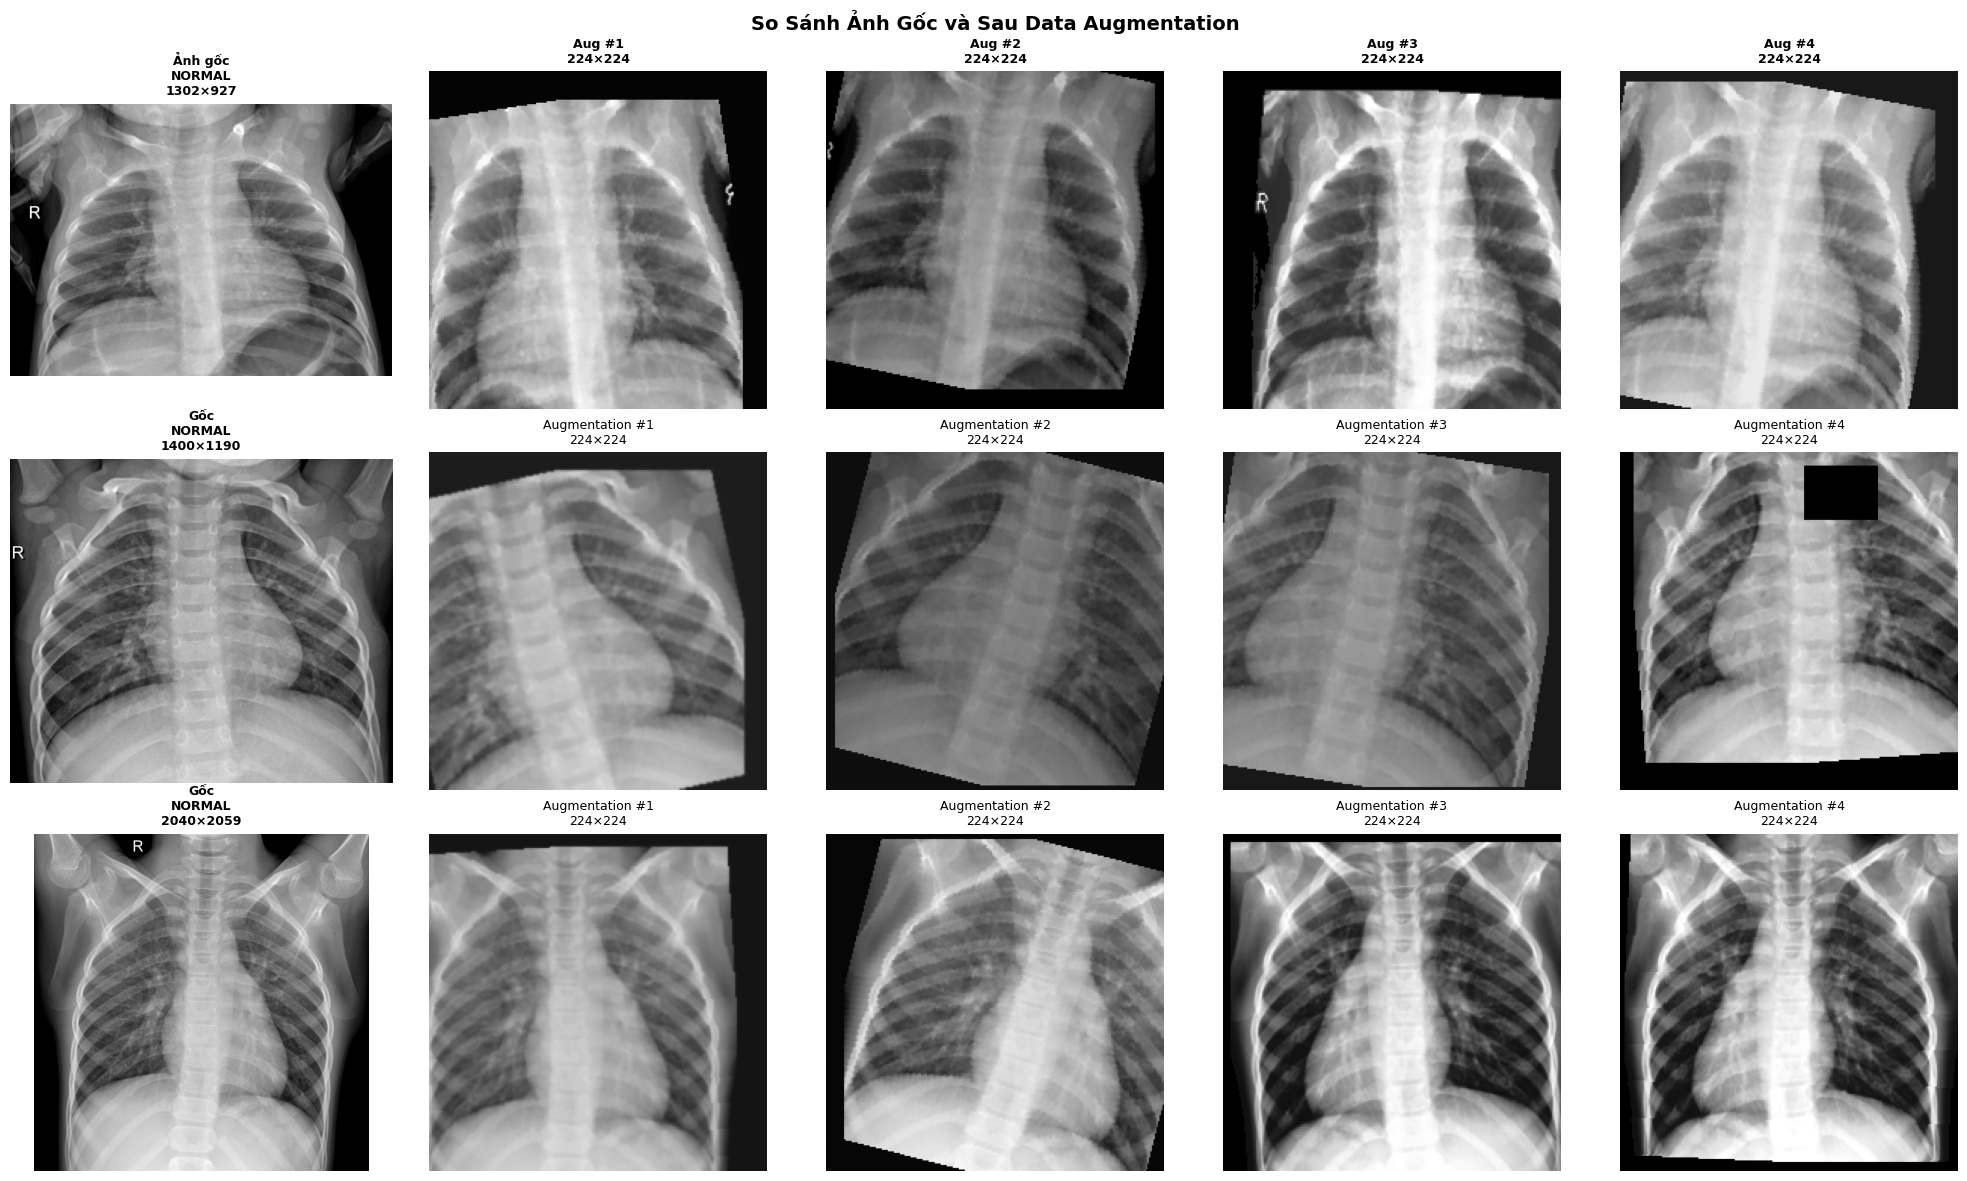

 Đã lưu: augmentation_comparison.png


In [ ]:

# TRỰC QUAN HÓA: SO SÁNH ẢNH GỐC VÀ SAU AUGMENTATION

def visualize_augmentation_comparison(df, num_samples=4):
    """So sánh ảnh gốc và sau augmentation"""
    fig, axes = plt.subplots(num_samples, 5, figsize=(20, num_samples * 4))

    mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    sample_rows = df.sample(n=num_samples, random_state=42).reset_index(drop=True)

    for row_i, (_, row) in enumerate(sample_rows.iterrows()):
        original_img = Image.open(row['path']).convert('RGB')

        # Cột 0: ảnh gốc
        axes[row_i, 0].imshow(original_img)
        axes[row_i, 0].set_title(f'Gốc\n{row["label"]}\n{original_img.size[0]}×{original_img.size[1]}',
                                  fontsize=9, fontweight='bold')
        axes[row_i, 0].axis('off')

        # Cột 1-4: 4 lần augmentation khác nhau
        for aug_i in range(1, 5):
            aug_tensor = train_transform(original_img)
            # Denormalize để hiển thị
            img_display = (aug_tensor * std_t + mean_t).permute(1, 2, 0).numpy()
            img_display = np.clip(img_display, 0, 1)

            axes[row_i, aug_i].imshow(img_display)
            axes[row_i, aug_i].set_title(f'Augmentation #{aug_i}\n224×224', fontsize=9)
            axes[row_i, aug_i].axis('off')

    # Thêm nhãn cột
    col_labels = ['Ảnh gốc', 'Aug #1', 'Aug #2', 'Aug #3', 'Aug #4']
    for col_i, label in enumerate(col_labels):
        axes[0, col_i].set_title(f'{label}\n' + axes[0, col_i].get_title().split('\n', 1)[-1],
                                  fontsize=9, fontweight='bold')

    plt.suptitle('So Sánh Ảnh Gốc và Sau Data Augmentation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('augmentation_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Đã lưu: augmentation_comparison.png")

visualize_augmentation_comparison(df, num_samples=3)

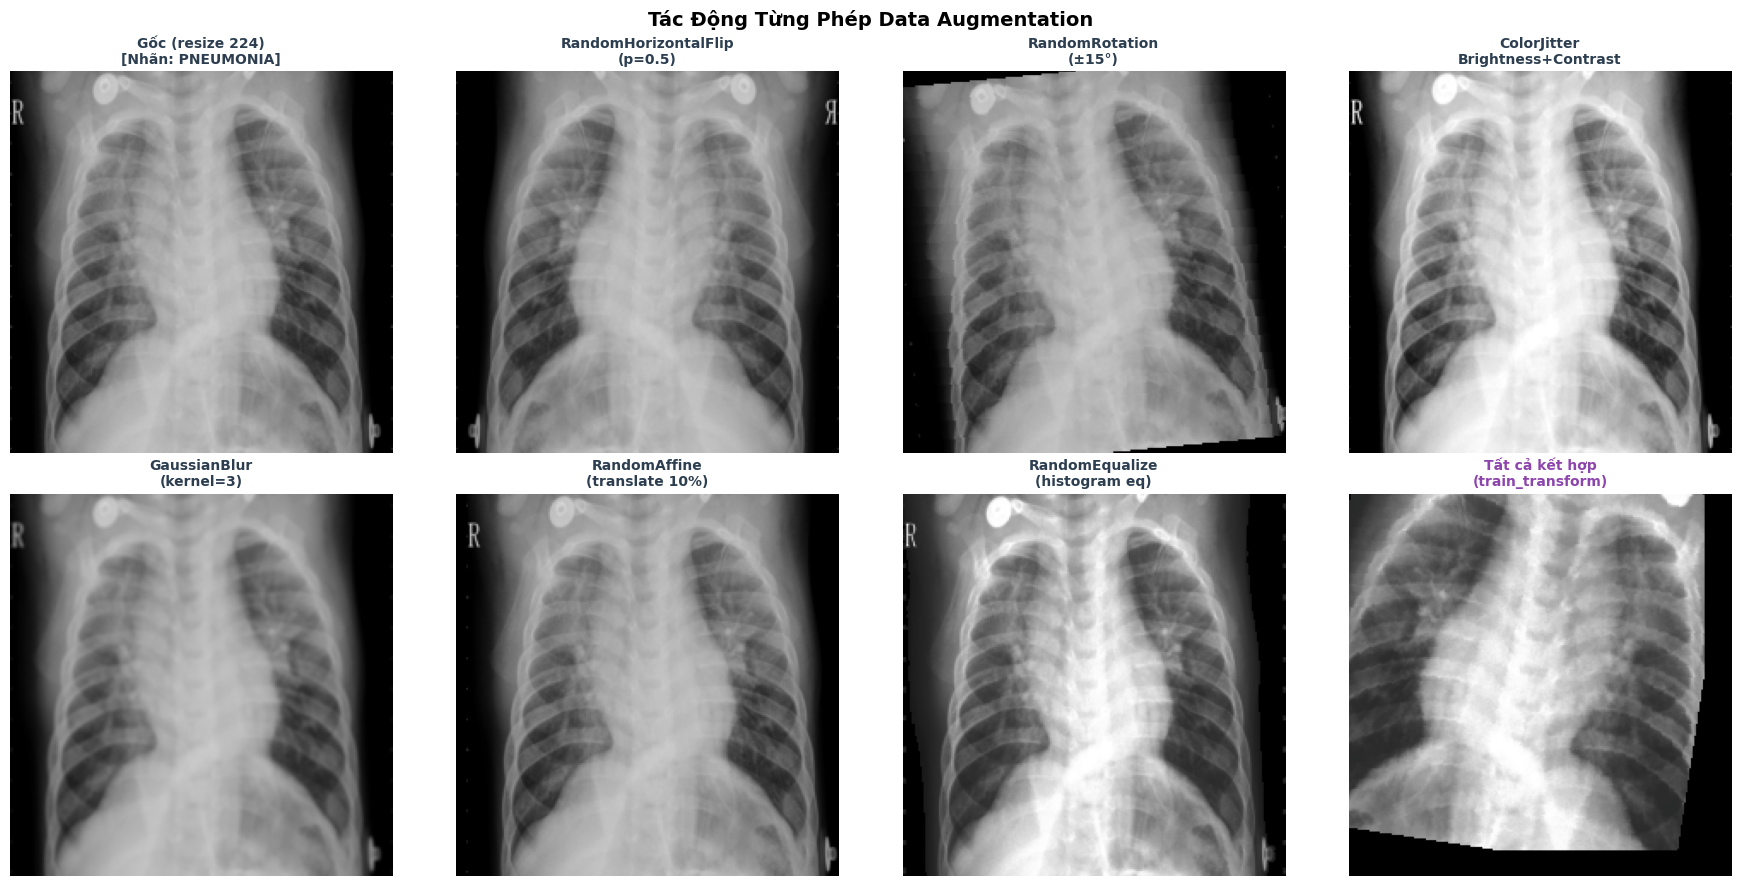

Đã lưu: augmentation_steps.png


In [ ]:

# TRỰC QUAN HÓA: TÁC ĐỘNG TỪNG PHÉP AUGMENTATION

def visualize_each_augmentation(df):
    """Hiển thị tác động từng phép augmentation riêng biệt"""
    sample_row = df.sample(n=1, random_state=7).iloc[0]
    original_img = Image.open(sample_row['path']).convert('RGB')

    aug_steps = [
        ('Gốc (resize 224)', transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE))
        ])),
        ('RandomHorizontalFlip\n(p=0.5)', transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=1.0)
        ])),
        ('RandomRotation\n(±15°)', transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomRotation(degrees=15, fill=0)
        ])),
        ('ColorJitter\nBrightness+Contrast', transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ColorJitter(brightness=0.3, contrast=0.3)
        ])),
        ('GaussianBlur\n(kernel=3)', transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.GaussianBlur(kernel_size=3, sigma=1.0)
        ])),
        ('RandomAffine\n(translate 10%)', transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))
        ])),
        ('RandomEqualize\n(histogram eq)', transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomEqualize(p=1.0)
        ])),
        ('Tất cả kết hợp\n(train_transform)', train_transform),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    for idx, (title, transform) in enumerate(aug_steps):
        ax = axes[idx // 4, idx % 4]
        aug_img = transform(original_img)

        if isinstance(aug_img, torch.Tensor):
            # Denormalize nếu đã normalize
            if aug_img.min() < 0:  # đã normalize
                aug_img = (aug_img * std_t + mean_t).permute(1, 2, 0).numpy()
            else:
                aug_img = aug_img.permute(1, 2, 0).numpy()
            aug_img = np.clip(aug_img, 0, 1)
        else:
            aug_img = np.array(aug_img)

        ax.imshow(aug_img, cmap='gray' if aug_img.ndim == 2 else None)
        color = '#2c3e50' if idx < len(aug_steps) - 1 else '#8e44ad'
        ax.set_title(title, fontsize=10, fontweight='bold', color=color)
        ax.axis('off')

        if idx == 0:
            ax.set_title(title + f'\n[Nhãn: {sample_row["label"]}]', fontsize=10, fontweight='bold')

    plt.suptitle('Tác Động Từng Phép Data Augmentation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('augmentation_steps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Đã lưu: augmentation_steps.png")

visualize_each_augmentation(df)

## 7. Dataset Class và DataLoader

In [ ]:
class ChestXRayDataset(Dataset):
    """Custom Dataset cho ảnh X-quang ngực"""

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        label = row['label_idx']
        try:
            image = Image.open(row['path']).convert('RGB')
        except Exception as e:
            print(f"Error loading {row['path']}: {e}")
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        if self.transform:
            image = self.transform(image)
        return image, label

# Tạo datasets
train_dataset = ChestXRayDataset(train_df, transform=train_transform)
val_dataset   = ChestXRayDataset(val_df,   transform=val_test_transform)
test_dataset  = ChestXRayDataset(test_df,  transform=val_test_transform)

BATCH_SIZE  = 32
NUM_WORKERS = 0  # Set 0 để tránh lỗi multiprocessing trong notebook

# Training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,        # ← Trộn ngẫu nhiên mỗi epoch — tránh model học thứ tự file
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Validation/Test: shuffle=False để đánh giá ổn định
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"   DataLoader đã khởi tạo:")
print(f"   Train batches : {len(train_loader)} ({BATCH_SIZE} ảnh/batch)")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

   DataLoader đã khởi tạo:
   Train batches : 128 (32 ảnh/batch)
   Val batches   : 37
   Test batches  : 19


### 8. Xây Dựng Mô Hình ViT Hybrid Cải Tiến

In [ ]:
from torchvision.models import densenet121, DenseNet121_Weights

class CNNBackbone(nn.Module):
    """
    DenseNet121 backbone cắt đến denseblock3.
    Output: 14×14×896 feature map (với input 224×224)
    """
    def __init__(self, pretrained=True):
        super().__init__()
        densenet = densenet121(
            weights=DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        )
        features = densenet.features

        # Giữ lại đến hết denseblock3 (bỏ denseblock4 và transition3)
        self.conv0      = features.conv0       # 7×7 conv, stride 2
        self.norm0      = features.norm0
        self.relu0      = features.relu0
        self.pool0      = features.pool0       # maxpool stride 2 → 56×56

        self.denseblock1  = features.denseblock1   # → 56×56, 256 ch
        self.transition1  = features.transition1   # → 28×28, 128 ch

        self.denseblock2  = features.denseblock2   # → 28×28, 512 ch
        self.transition2  = features.transition2   # → 14×14, 256 ch

        self.denseblock3  = features.denseblock3   # → 14×14, 896 ch

        # DenseNet121: growth_rate=32, block_config=(6,12,24,16)
        # Sau denseblock3: 256 + 24×32 = 256 + 768 = 1024...
        # Thực tế transition2 output = 256, denseblock3 thêm 24×32=768 → 1024
        # Nhưng torchvision tính transition output = floor(in/2):
        #   denseblock2 out = 128 + 12×32 = 512 → transition2 out = 256
        #   denseblock3 out = 256 + 24×32 = 256 + 768 = 1024
        self.out_channels = 1024

        self._freeze_early_layers()

    def _freeze_early_layers(self):
        # Freeze conv0, norm0, denseblock1 (tương đương conv1/bn1/layer1 của ResNet)
        frozen_modules = (
            list(self.conv0.parameters()) +
            list(self.norm0.parameters()) +
            list(self.denseblock1.parameters())
        )
        for param in frozen_modules:
            param.requires_grad = False

        # Giữ nguyên BN stats của các layer frozen
        for module in [self.norm0] + list(self.denseblock1.modules()):
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

    def train(self, mode=True):
        super().train(mode)
        # Ép BN frozen về eval mode sau khi set train mode
        for module in [self.norm0] + list(self.denseblock1.modules()):
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        return self

    def forward(self, x):
        x = self.pool0(self.relu0(self.norm0(self.conv0(x))))  # 56×56
        x = self.transition1(self.denseblock1(x))              # 28×28
        x = self.transition2(self.denseblock2(x))              # 14×14
        x = self.denseblock3(x)                                # 14×14, 1024 ch
        return x


class HybridViT(nn.Module):
    def __init__(self, num_classes=2, embed_dim=512, depth=6, num_heads=4,
                 mlp_ratio=4, dropout=0.1, attn_dropout=0.1,
                 drop_path_rate=0.1, pretrained_backbone=True):
        super().__init__()
        self.backbone = CNNBackbone(pretrained=pretrained_backbone)
        self.patch_embed = nn.Sequential(
            nn.Conv2d(self.backbone.out_channels, embed_dim, kernel_size=1),
            nn.BatchNorm2d(embed_dim),
            Rearrange('b c h w -> b (h w) c')
        )
        self.num_patches = 14 * 14  # = 196 với input 224×224 (không đổi)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.transformer = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout, attn_dropout, dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes)
        )
        self._init_weights()

    # _init_weights và forward giữ nguyên không đổi
    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.shape[0]
        x = self.backbone(x)                          # (B, 1024, 14, 14)
        x = self.patch_embed(x)                       # (B, 196, embed_dim)
        cls_tokens = self.cls_token.expand(B, -1, -1) # (B, 1, embed_dim)
        x = torch.cat([cls_tokens, x], dim=1)         # (B, 197, embed_dim)
        x = self.pos_drop(x + self.pos_embed)
        for block in self.transformer:
            x = block(x)
        x = self.norm(x)
        return self.head(x[:, 0])

## 9. Training Configuration

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
from timm.models.layers import DropPath   # ✅ thêm import

# ============================================================
# BLOCK 1: EfficientMultiHeadAttention — không đổi
# ============================================================
class EfficientMultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.embed_dim  = embed_dim
        self.num_heads  = num_heads
        self.head_dim   = embed_dim // num_heads
        self.qkv        = nn.Linear(embed_dim, embed_dim * 3)
        self.proj       = nn.Linear(embed_dim, embed_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)
        self.scale      = self.head_dim ** -0.5

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_dropout(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_dropout(x)
        return x

# ============================================================
# BLOCK 2: MLP — không đổi
# ============================================================
class MLP(nn.Module):
    def __init__(self, embed_dim, mlp_ratio=4, dropout=0.1):
        super().__init__()
        hidden_dim    = int(embed_dim * mlp_ratio)
        self.fc1      = nn.Linear(embed_dim, hidden_dim)
        self.act      = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2      = nn.Linear(hidden_dim, embed_dim)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout2(self.fc2(self.dropout1(self.act(self.fc1(x)))))

# ============================================================
# BLOCK 3: TransformerBlock — FIX: thêm DropPath thực sự
# ============================================================
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads=4, mlp_ratio=4,
                 dropout=0.1, attn_dropout=0.1, drop_path=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn  = EfficientMultiHeadAttention(embed_dim, num_heads, attn_dropout)
        self.mlp   = MLP(embed_dim, mlp_ratio, dropout)

        # ✅ FIX: tạo DropPath layer thực sự thay vì bỏ qua tham số
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x):
        # ✅ FIX: áp dụng drop_path vào residual connection
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

# ============================================================
# BLOCK 4: Khởi tạo model + training config
# ============================================================
model = HybridViT(
    num_classes=len(CLASSES),
    embed_dim=512, depth=6, num_heads=4,
    mlp_ratio=4, dropout=0.1, attn_dropout=0.05,
    drop_path_rate=0.05,        # ✅ tăng từ 0.0 → 0.1 để DropPath có tác dụng
    pretrained_backbone=True
).to(device)

# Class weights
counts       = train_df['label_idx'].value_counts().sort_index().values
total        = counts.sum()
weights      = total / (len(CLASSES) * counts)
class_weights = torch.FloatTensor(weights).to(device)
print(f"Class Weights: {class_weights}")

# Hyperparameters
EPOCHS         = 30
LEARNING_RATE  = 1e-4
WEIGHT_DECAY   = 0.01
WARMUP_EPOCHS  = 5
LABEL_SMOOTHING = 0.025  # ✅ tăng từ 0.0 → 0.1 giúp giảm overconfidence

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def get_lr_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = get_lr_scheduler(optimizer, WARMUP_EPOCHS, EPOCHS)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
scaler    = GradScaler()

total_params = sum(p.numel() for p in model.parameters())
print(f"Mô hình sẵn sàng | LR={LEARNING_RATE} | Params: {total_params:,}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 206MB/s]


Class Weights: tensor([1.8475, 0.6855], device='cuda:0')
Mô hình sẵn sàng | LR=0.0001 | Params: 23,941,762


## 10. Huấn Luyện Mô Hình

In [ ]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif self._is_improvement(score):
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def _is_improvement(self, score):
        if self.mode == 'min':
            return score < self.best_score - self.min_delta
        return score > self.best_score + self.min_delta


def train_epoch(model, dataloader, criterion, optimizer, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(dataloader, desc="Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        # Added gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})
    return running_loss / total, correct / total


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            # ✅ Lấy probability TRƯỚC khi argmax
            probs = torch.softmax(outputs, dim=1)[:, 1]  # xác suất class PNEUMONIA
            _, predicted = outputs.max(1)

            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())   # ✅ thu thập probability

    # ✅ Đổi tên biến: weighted → val_f1_weighted cho đúng
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    return running_loss / total, correct / total, f1_weighted, all_preds, all_labels, all_probs

print(" Training functions đã được định nghĩa với gradient clipping.")

 Training functions đã được định nghĩa với gradient clipping.


In [ ]:
import time
import torch
from sklearn.metrics import roc_auc_score

# =========================================================
# FORMAT TIME
# =========================================================
def format_duration(seconds):
    """Định dạng thời gian hh:mm:ss hoặc mm:ss"""

    seconds = max(0, int(seconds))

    h, rem = divmod(seconds, 3600)
    m, s = divmod(rem, 60)

    if h > 0:
        return f"{h:d}h {m:02d}m {s:02d}s"

    return f"{m:02d}m {s:02d}s"


# =========================================================
# HISTORY
# =========================================================
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'val_auc': [],
    'lr': [],
    'epoch_time': []
}


# =========================================================
# EARLY STOPPING
# =========================================================
early_stopping = EarlyStopping(
    patience=7,
    min_delta=0.001,
    mode='max'   # AUC càng cao càng tốt
)


# =========================================================
# BEST METRICS
# =========================================================
best_val_loss = float('inf')
best_val_acc  = 0.0
best_val_auc  = 0.0
best_val_f1   = 0.0
best_epoch    = 0

MODEL_SAVE_PATH = 'hybrid_vit_pneumonia_best_v2.pth'


# =========================================================
# START TRAINING
# =========================================================
print("Bắt đầu huấn luyện...")
print("=" * 60)

training_start_time = time.perf_counter()


# =========================================================
# TRAIN LOOP
# =========================================================
for epoch in range(EPOCHS):

    epoch_start_time = time.perf_counter()

    current_lr = optimizer.param_groups[0]['lr']

    print(f"\nEpoch {epoch+1}/{EPOCHS} | LR: {current_lr:.2e}")
    print("-" * 40)

    # =====================================================
    # TRAIN
    # =====================================================
    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    # =====================================================
    # VALIDATION
    # =====================================================
    (
        val_loss,
        val_acc,
        val_f1_macro,
        val_preds,
        val_labels,
        val_probs
    ) = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # =====================================================
    # CALCULATE AUC
    # =====================================================
    try:

        # DÙNG PROBABILITIES, KHÔNG DÙNG ARGMAX
        val_auc = roc_auc_score(
            val_labels,
            val_probs
        )

    except ValueError as e:

        print(f"  [Warning] Không tính được AUC: {e}")

        val_auc = 0.0

    # =====================================================
    # UPDATE SCHEDULER
    # =====================================================
    scheduler.step()

    # =====================================================
    # TIME
    # =====================================================
    epoch_time = (
        time.perf_counter()
        - epoch_start_time
    )

    elapsed_time = (
        time.perf_counter()
        - training_start_time
    )

    avg_epoch_time = (
        elapsed_time / (epoch + 1)
    )

    eta_seconds = (
        avg_epoch_time
        * (EPOCHS - epoch - 1)
    )

    # =====================================================
    # SAVE HISTORY
    # =====================================================
    history['train_loss'].append(train_loss)

    history['train_acc'].append(train_acc)

    history['val_loss'].append(val_loss)

    history['val_acc'].append(val_acc)

    history['val_f1'].append(val_f1_macro)

    history['val_auc'].append(val_auc)

    history['lr'].append(current_lr)

    history['epoch_time'].append(epoch_time)

    # =====================================================
    # LOGGING
    # =====================================================
    print(
        f"Train      : "
        f"Loss {train_loss:.4f} | "
        f"Acc {train_acc*100:.2f}%"
    )

    print(
        f"Validation : "
        f"Loss {val_loss:.4f} | "
        f"Acc {val_acc*100:.2f}% | "
        f"F1 {val_f1_macro:.4f} | "
        f"AUC {val_auc:.4f}"
    )

    print(
        f"Thời gian  : "
        f"Epoch {epoch_time:.1f}s | "
        f"Tổng {format_duration(elapsed_time)} | "
        f"ETA {format_duration(eta_seconds)}"
    )

    # =====================================================
    # SAVE BEST MODEL
    # =====================================================
    is_best = False

    # Ưu tiên AUC
    if val_auc > best_val_auc:

        is_best = True

    # Nếu AUC gần bằng nhau → ưu tiên F1
    elif (
        abs(val_auc - best_val_auc) < 1e-4
        and val_f1_macro > best_val_f1
    ):

        is_best = True

    if is_best:

        best_val_loss = val_loss

        best_val_acc = val_acc

        best_val_auc = val_auc

        best_val_f1 = val_f1_macro

        best_epoch = epoch + 1

        torch.save({

            'epoch':
                epoch,

            'model_state_dict':
                model.state_dict(),

            'optimizer_state_dict':
                optimizer.state_dict(),

            'scaler_state_dict':
                scaler.state_dict(),

            'val_loss':
                val_loss,

            'val_acc':
                val_acc,

            'val_f1_macro':
                val_f1_macro,

            'val_auc':
                val_auc

        }, MODEL_SAVE_PATH)

        print(
            f"  ✅ Saved best model → "
            f"AUC {val_auc:.4f} | "
            f"F1 {val_f1_macro:.4f} | "
            f"Acc {val_acc*100:.2f}%"
        )

    # =====================================================
    # EARLY STOPPING
    # =====================================================
    early_stopping(val_auc)

    if early_stopping.early_stop:

        print(
            f"\nEarly stopping tại epoch "
            f"{epoch+1}"
        )

        break

    # =====================================================
    # CLEAR CUDA CACHE
    # =====================================================
    torch.cuda.empty_cache()


# =========================================================
# TRAINING SUMMARY
# =========================================================
total_training_time = (
    time.perf_counter()
    - training_start_time
)

completed_epochs = len(
    history['train_loss']
)

avg_epoch_time = (
    total_training_time / completed_epochs
    if completed_epochs > 0 else 0.0
)

print("\n" + "=" * 60)

print("Huấn luyện hoàn tất!")

print(
    f"  Best epoch : {best_epoch} | "
    f"AUC {best_val_auc:.4f} | "
    f"F1 {best_val_f1:.4f} | "
    f"Acc {best_val_acc*100:.2f}%"
)

print(
    f"  Tổng thời gian  : "
    f"{format_duration(total_training_time)} "
    f"({total_training_time:.1f}s)"
)

print(
    f"  Trung bình/epoch: "
    f"{avg_epoch_time:.1f}s"
)

Bắt đầu huấn luyện...

Epoch 1/30 | LR: 2.00e-05
----------------------------------------


Training:   0%|          | 0/128 [00:00<?, ?it/s]

Validating:   0%|          | 0/37 [00:00<?, ?it/s]

Train      : Loss 0.3261 | Acc 89.64%
Validation : Loss 0.3130 | Acc 87.77% | F1 0.8833 | AUC 0.9848
Thời gian  : Epoch 137.0s | Tổng 02m 16s | ETA 1h 06m 12s
  ✅ Saved best model → AUC 0.9848 | F1 0.8833 | Acc 87.77%

Epoch 2/30 | LR: 4.00e-05
----------------------------------------


Training:   0%|          | 0/128 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/37 [00:00<?, ?it/s]

Train      : Loss 0.1366 | Acc 98.39%
Validation : Loss 0.1797 | Acc 97.01% | F1 0.9703 | AUC 0.9956
Thời gian  : Epoch 129.8s | Tổng 37m 40s | ETA 28m 48s

Epoch 18/30 | LR: 5.31e-05
----------------------------------------


Training:   0%|          | 0/128 [00:00<?, ?it/s]

Validating:   0%|          | 0/37 [00:00<?, ?it/s]

Train      : Loss 0.1244 | Acc 98.80%
Validation : Loss 0.1841 | Acc 97.43% | F1 0.9743 | AUC 0.9961
Thời gian  : Epoch 132.7s | Tổng 39m 53s | ETA 26m 35s

Early stopping tại epoch 18

Huấn luyện hoàn tất!
  Best epoch : 11 | AUC 0.9975 | F1 0.9760 | Acc 97.60%
  Tổng thời gian  : 39m 53s (2393.4s)
  Trung bình/epoch: 133.0s


## 11. Đánh Giá Mô Hình

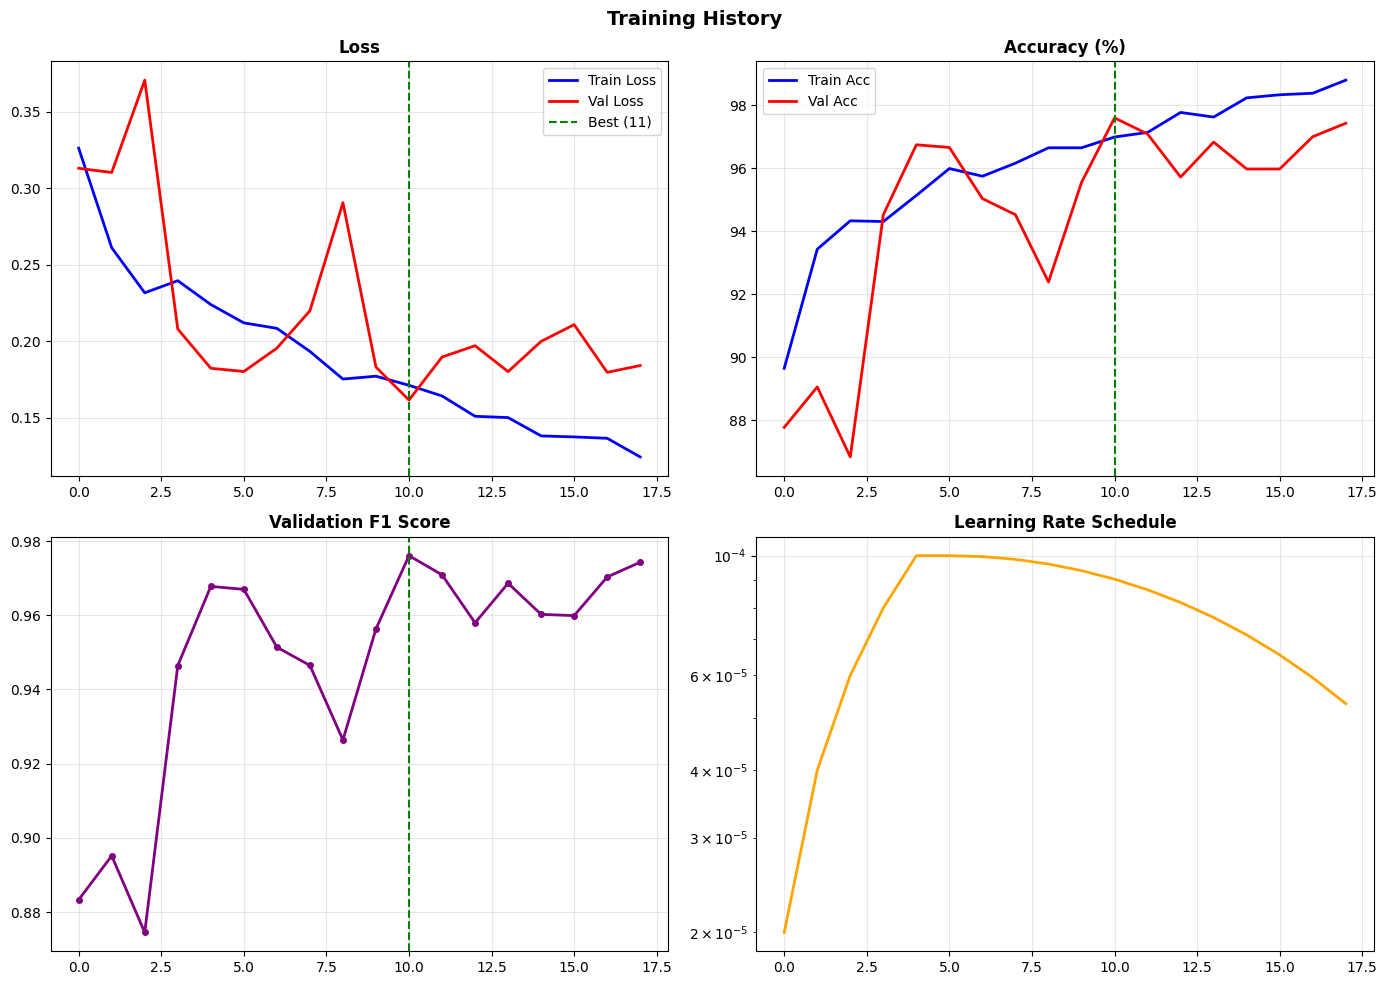

In [ ]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
axes[0,0].plot(history['val_loss'],   label='Val Loss',   color='red',  linewidth=2)
axes[0,0].axvline(x=best_epoch-1, color='green', linestyle='--', label=f'Best ({best_epoch})')
axes[0,0].set_title('Loss', fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot([a*100 for a in history['train_acc']], label='Train Acc', color='blue', linewidth=2)
axes[0,1].plot([a*100 for a in history['val_acc']],   label='Val Acc',   color='red',  linewidth=2)
axes[0,1].axvline(x=best_epoch-1, color='green', linestyle='--')
axes[0,1].set_title('Accuracy (%)', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(history['val_f1'], color='purple', linewidth=2, marker='o', markersize=4)
axes[1,0].axvline(x=best_epoch-1, color='green', linestyle='--')
axes[1,0].set_title('Validation F1 Score', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(history['lr'], color='orange', linewidth=2)
axes[1,1].set_title('Learning Rate Schedule', fontweight='bold')
axes[1,1].set_yscale('log')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

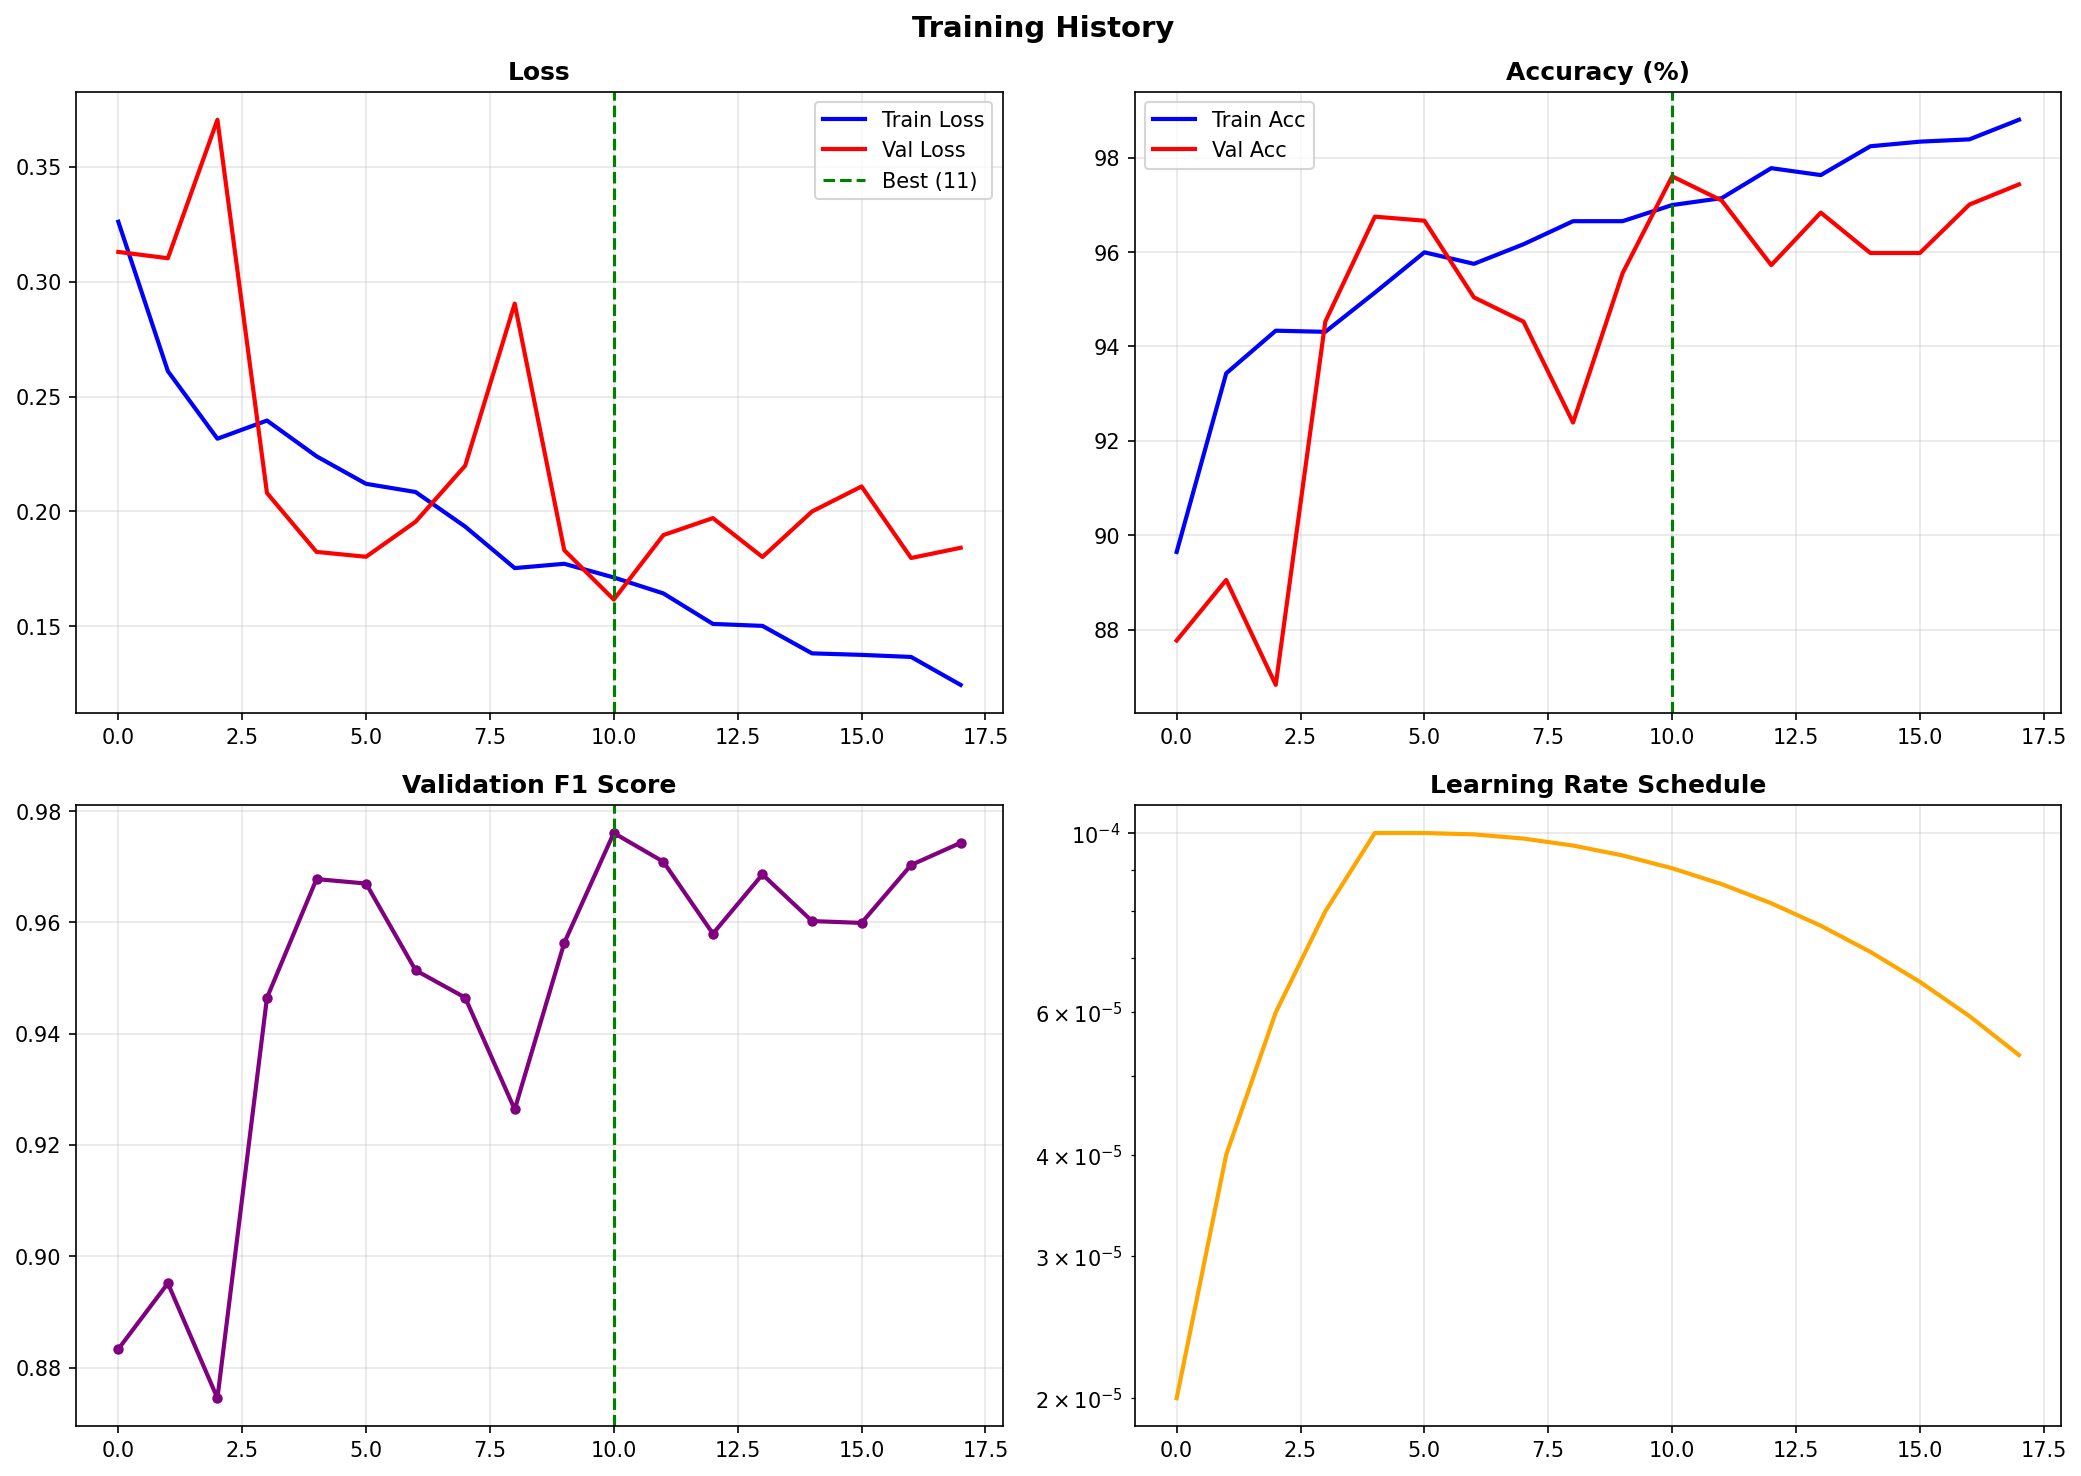

In [ ]:
from IPython.display import Image, display
if os.path.exists('training_history.png'):
    display(Image('training_history.png'))
else:
    print('Không tìm thấy file training_history.png. Vui lòng chạy lại ô vẽ đồ thị.')

 Loaded best model from epoch 11


Validating:   0%|          | 0/19 [00:00<?, ?it/s]


FINAL RESULTS ON TEST SET
   Test Accuracy : 97.95%
   Test F1 Score : 0.9796
   Test Loss     : 0.1521

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9565    0.9686    0.9625       159
   PNEUMONIA     0.9882    0.9836    0.9859       427

    accuracy                         0.9795       586
   macro avg     0.9724    0.9761    0.9742       586
weighted avg     0.9796    0.9795    0.9796       586


CLINICAL PERFORMANCE SUMMARY
  Sensitivity (Recall)   = 98.36%
  Specificity            = 96.86%
  FNR (Miss Rate)        = 1.64%  ← CRITICAL


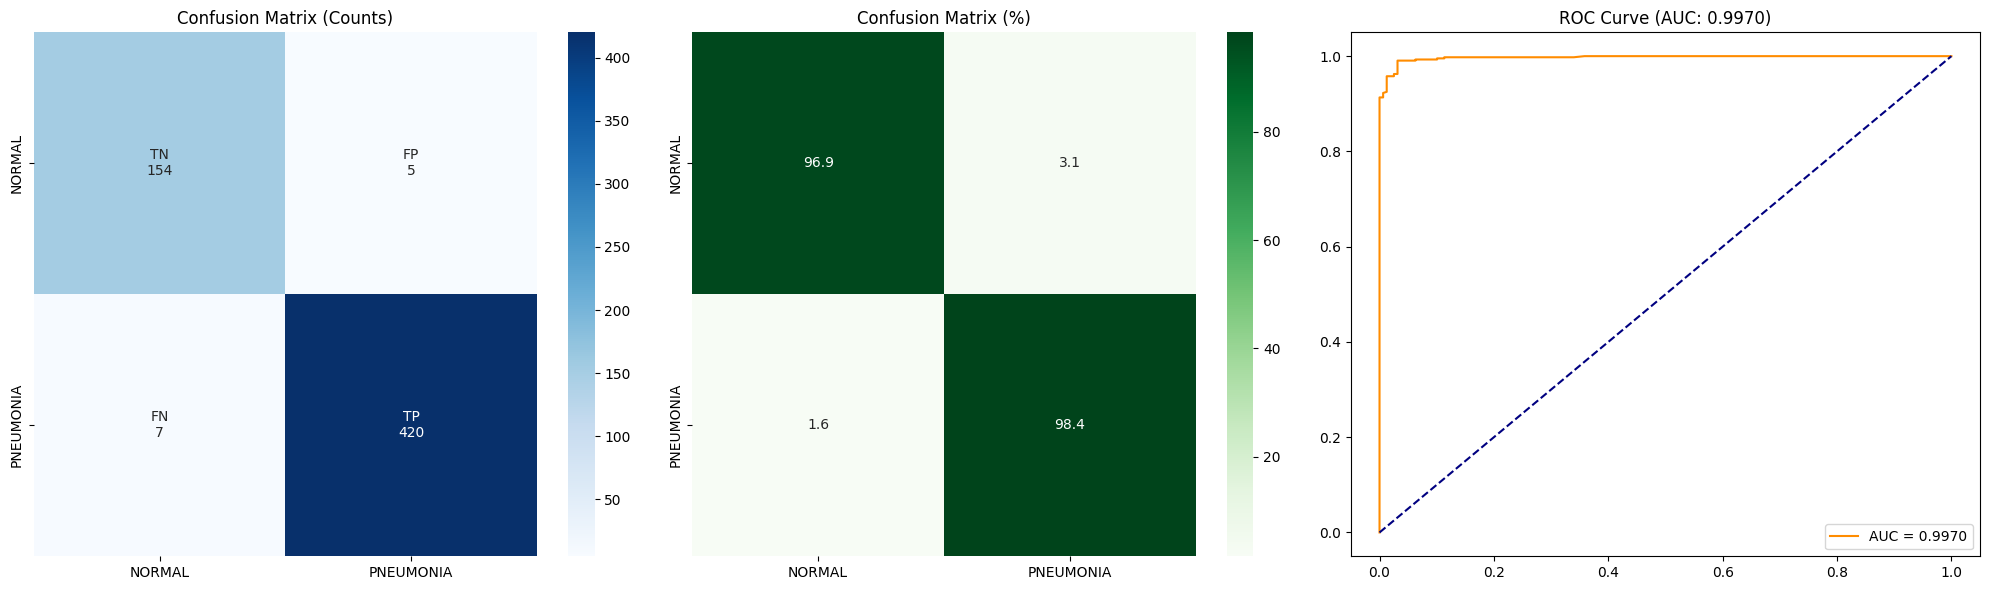

In [ ]:
import PIL.Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Ensure correct Image import
from PIL import Image

# Load best model and evaluate on test set
try:
    checkpoint = torch.load(MODEL_SAVE_PATH, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f" Loaded best model from epoch {checkpoint['epoch']+1}")

    # ✅ Corrected: Unpack 6 values instead of 5
    test_loss, test_acc, test_f1, test_preds, test_labels, test_probs = validate(
        model, test_loader, criterion, device
    )

    print("\n" + "="*50)
    print("FINAL RESULTS ON TEST SET")
    print("="*50)
    print(f"   Test Accuracy : {test_acc*100:.2f}%")
    print(f"   Test F1 Score : {test_f1:.4f}")
    print(f"   Test Loss     : {test_loss:.4f}")

    print("\nClassification Report:")
    print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, test_preds)
    TN, FP, FN, TP = cm.ravel()

    # Clinical Metrics
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    ppv         = TP / (TP + FP) if (TP + FP) > 0 else 0
    npv         = TN / (TN + FN) if (TN + FN) > 0 else 0
    fnr         = FN / (FN + TP) if (FN + TP) > 0 else 0
    fpr         = FP / (FP + TN) if (FP + TN) > 0 else 0

    print("\n" + "="*60)
    print("CLINICAL PERFORMANCE SUMMARY")
    print("="*60)
    print(f"  Sensitivity (Recall)   = {sensitivity*100:.2f}%")
    print(f"  Specificity            = {specificity*100:.2f}%")
    print(f"  FNR (Miss Rate)        = {fnr*100:.2f}%  ← CRITICAL")
    print("="*60)

    # --- Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # 1. Confusion Matrix (Counts)
    labels_cm = np.array([[f'TN\n{TN}', f'FP\n{FP}'], [f'FN\n{FN}', f'TP\n{TP}']])
    sns.heatmap(cm, annot=labels_cm, fmt='', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
    axes[0].set_title('Confusion Matrix (Counts)')

    # 2. Confusion Matrix (Normalized)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
    axes[1].set_title('Confusion Matrix (%)')

    # 3. ROC Curve
    fpr_val, tpr_val, _ = roc_curve(test_labels, test_probs)
    roc_auc_val = auc(fpr_val, tpr_val)
    axes[2].plot(fpr_val, tpr_val, color='darkorange', label=f'AUC = {roc_auc_val:.4f}')
    axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[2].set_title(f'ROC Curve (AUC: {roc_auc_val:.4f})')
    axes[2].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig('confusion_matrix_roc.png', dpi=150)
    plt.show()

except Exception as e:
    print(f"Error: {e}")

In [ ]:
# TỐI ƯU THRESHOLD CHO PNEUMONIA DETECTION
import torch.nn.functional as F
import numpy as np

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        all_probs.extend(probs[:, 1].cpu().numpy())  # xác suất PNEUMONIA
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

print("=" * 60)
print("TỐI ƯU THRESHOLD")
print("=" * 60)

best_f1 = 0
best_threshold = 0.5

for threshold in [0.2, 0.3, 0.35, 0.4, 0.45, 0.5]:
    preds = (all_probs >= threshold).astype(int)
    f1 = f1_score(all_labels, preds, average='weighted')
    acc = accuracy_score(all_labels, preds)

    print(f"\nThreshold = {threshold}")
    print(classification_report(all_labels, preds,
          target_names=CLASSES, digits=4))

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\n Best threshold : {best_threshold}")
print(f" Best F1 Score  : {best_f1:.4f}")

TỐI ƯU THRESHOLD

Threshold = 0.2
              precision    recall  f1-score   support

      NORMAL     0.9745    0.9623    0.9684       159
   PNEUMONIA     0.9860    0.9906    0.9883       427

    accuracy                         0.9829       586
   macro avg     0.9803    0.9764    0.9783       586
weighted avg     0.9829    0.9829    0.9829       586


Threshold = 0.3
              precision    recall  f1-score   support

      NORMAL     0.9745    0.9623    0.9684       159
   PNEUMONIA     0.9860    0.9906    0.9883       427

    accuracy                         0.9829       586
   macro avg     0.9803    0.9764    0.9783       586
weighted avg     0.9829    0.9829    0.9829       586


Threshold = 0.35
              precision    recall  f1-score   support

      NORMAL     0.9747    0.9686    0.9716       159
   PNEUMONIA     0.9883    0.9906    0.9895       427

    accuracy                         0.9846       586
   macro avg     0.9815    0.9796    0.9805       586
weigh

 Loaded best model từ epoch 11


Validating:   0%|          | 0/19 [00:00<?, ?it/s]

KẾT QUẢ TRÊN TẬP TEST
   Test Accuracy : 97.95%
   Test F1 Score : 0.9796
   Test Loss     : 0.1521

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9565    0.9686    0.9625       159
   PNEUMONIA     0.9882    0.9836    0.9859       427

    accuracy                         0.9795       586
   macro avg     0.9724    0.9761    0.9742       586
weighted avg     0.9796    0.9795    0.9796       586


BẢNG MA TRẬN NHẦM LẪN (SỐ LƯỢNG MẪU)
  TN (True Negative)  =  154  → Thực tế NORMAL,    Dự đoán NORMAL    ✓
  FP (False Positive) =    5  → Thực tế NORMAL,    Dự đoán PNEUMONIA ✗
  FN (False Negative) =    7  → Thực tế PNEUMONIA, Dự đoán NORMAL    ✗
  TP (True Positive)  =  420  → Thực tế PNEUMONIA, Dự đoán PNEUMONIA ✓
  Tổng mẫu test      =  586

CHỈ SỐ LÂM SÀNG
  Sensitivity (Recall)   = 98.36%
  Specificity            = 96.86%
  PPV (Precision)        = 98.82%
  NPV                    = 95.65%
  FNR (Miss Rate)        = 1.64%  ← ⚠️  NGUY H

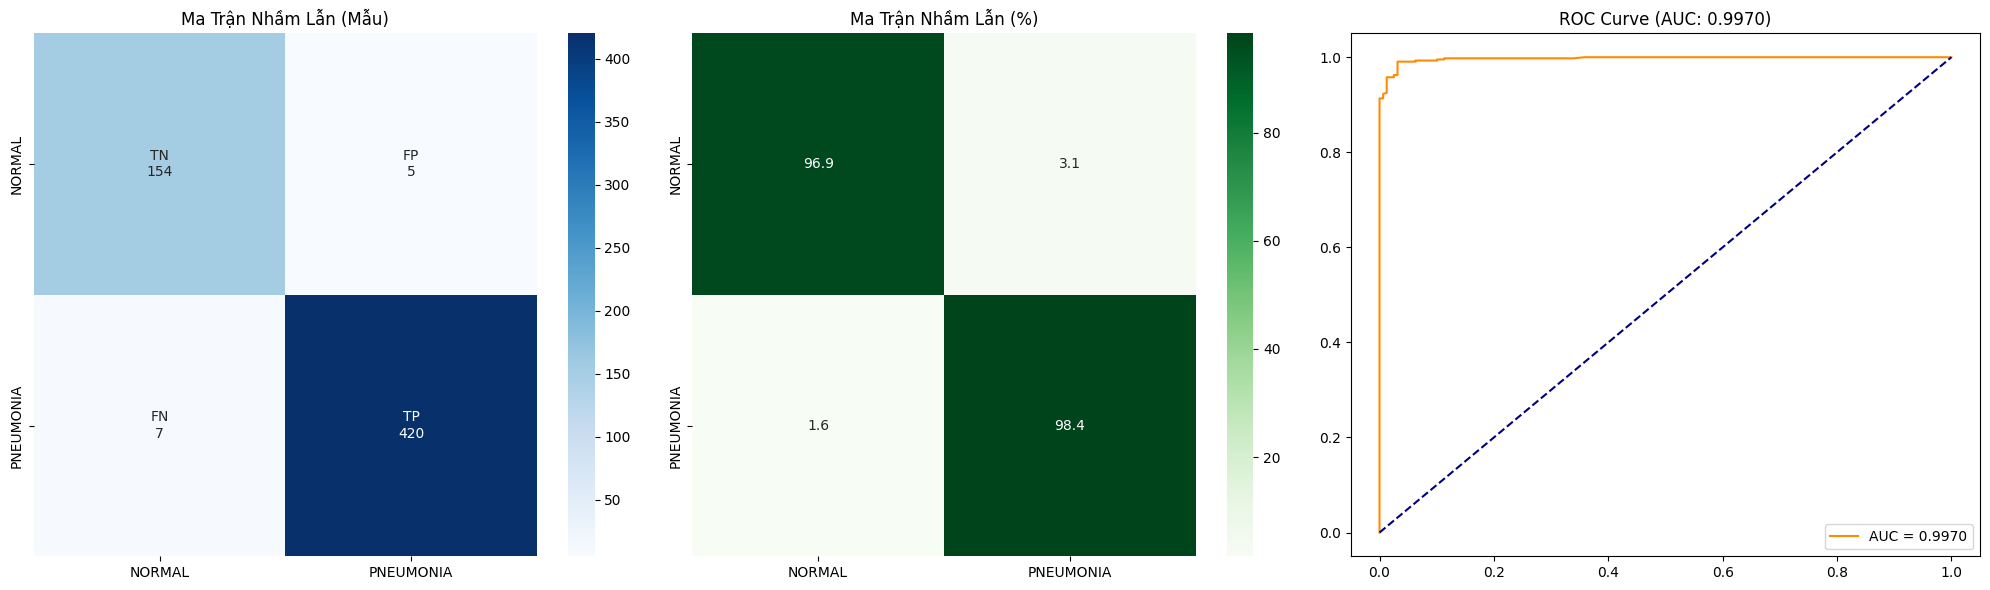

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc

# Cập nhật tên file khớp với ô training
MODEL_SAVE_PATH = 'hybrid_vit_pneumonia_best_v2.pth'

# Load best model và đánh giá trên test set
try:
    checkpoint = torch.load(MODEL_SAVE_PATH, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f" Loaded best model từ epoch {checkpoint['epoch']+1}")

    # FIX: Unpack 6 values instead of 5 to match updated validate() function
    test_loss, test_acc, test_f1, test_preds, test_labels, test_probs = validate(
        model, test_loader, criterion, device
    )

    print("KẾT QUẢ TRÊN TẬP TEST")
    print(f"   Test Accuracy : {test_acc*100:.2f}%")
    print(f"   Test F1 Score : {test_f1:.4f}")
    print(f"   Test Loss     : {test_loss:.4f}")

    print("\nClassification Report:")
    print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=4))

    # ============================================================
    # CONFUSION MATRIX VỚI NHÃN TN, FP, FN, TP RÕ RÀNG
    # ============================================================
    cm = confusion_matrix(test_labels, test_preds)
    TN, FP, FN, TP = cm.ravel()

    print("\n" + "="*50)
    print("BẢNG MA TRẬN NHẦM LẪN (SỐ LƯỢNG MẪU)")
    print("="*50)
    print(f"  TN (True Negative)  = {TN:4d}  → Thực tế NORMAL,    Dự đoán NORMAL    ✓")
    print(f"  FP (False Positive) = {FP:4d}  → Thực tế NORMAL,    Dự đoán PNEUMONIA ✗")
    print(f"  FN (False Negative) = {FN:4d}  → Thực tế PNEUMONIA, Dự đoán NORMAL    ✗")
    print(f"  TP (True Positive)  = {TP:4d}  → Thực tế PNEUMONIA, Dự đoán PNEUMONIA ✓")
    print(f"  Tổng mẫu test      = {TN+FP+FN+TP:4d}")
    print("="*50)


    # ============================================================
    # CHỈ SỐ LÂM SÀNG
    # ============================================================
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    ppv         = TP / (TP + FP) if (TP + FP) > 0 else 0
    npv         = TN / (TN + FN) if (TN + FN) > 0 else 0
    fnr         = FN / (FN + TP) if (FN + TP) > 0 else 0
    fpr         = FP / (FP + TN) if (FP + TN) > 0 else 0

    print("\n" + "="*60)
    print("CHỈ SỐ LÂM SÀNG")
    print("="*60)
    print(f"  Sensitivity (Recall)   = {sensitivity*100:.2f}%")
    print(f"  Specificity            = {specificity*100:.2f}%")
    print(f"  PPV (Precision)        = {ppv*100:.2f}%")
    print(f"  NPV                    = {npv*100:.2f}%")
    print(f"  FNR (Miss Rate)        = {fnr*100:.2f}%  ← ⚠️  NGUY HIỂM NHẤT")
    print(f"  FPR (Fall-out)         = {fpr*100:.2f}%")
    print("="*60)

    # --- Vẽ figure ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Subplot 1: Counts
    labels_cm = np.array([[f"TN\n{TN}", f"FP\n{FP}"], [f"FN\n{FN}", f"TP\n{TP}"]])
    sns.heatmap(cm, annot=labels_cm, fmt='', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
    axes[0].set_title('Ma Trận Nhầm Lẫn (Mẫu)')

    # Subplot 2: %
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
    axes[1].set_title('Ma Trận Nhầm Lẫn (%)')

    # Subplot 3: ROC
    fpr_curve, tpr_curve, _ = roc_curve(test_labels, test_probs)
    roc_auc = auc(fpr_curve, tpr_curve)
    axes[2].plot(fpr_curve, tpr_curve, color='darkorange', label=f'AUC = {roc_auc:.4f}')
    axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[2].set_title(f'ROC Curve (AUC: {roc_auc:.4f})')
    axes[2].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig('confusion_matrix_roc.png', dpi=150)
    plt.show()

except Exception as e:
    print(f"Lỗi: {e}")

PR-AUC (Precision-Recall AUC)
  ROC-AUC  = 0.9970
  PR-AUC   = 0.9989

  Tại sao cần PR-AUC trong y tế?
  • ROC-AUC dùng TN trong mẫu số → bị thổi phồng khi NORMAL >> PNEUMONIA
  • PR-AUC chỉ tập trung vào class DƯƠNG TÍNH (PNEUMONIA)
    → Phản ánh trung thực hơn khả năng phát hiện bệnh
  • PR-AUC = 1.0: hoàn hảo | PR-AUC = tỷ lệ positive: mô hình ngẫu nhiên

95% CONFIDENCE INTERVALS (Bootstrap, n=1000)
Chỉ số                   Điểm ước lượng                 95% CI Ghi chú
---------------------------------------------------------------------------
Sensitivity ⚠️                 98.13%   [96.66% – 99.30%]  
Specificity                    96.86%   [94.05% – 99.37%]  
PPV (Precision)                98.82%   [97.72% – 99.77%]  
NPV                            95.06%   [91.30% – 98.13%]  
FNR ⚠️                          1.87%   [0.70% – 3.34%]  ← BỎ SÓT VIÊM PHỔI
FPR                             3.14%   [0.63% – 5.95%]  
Accuracy                       97.78%   [96.42% – 98.81%]  
ROC-AUC    

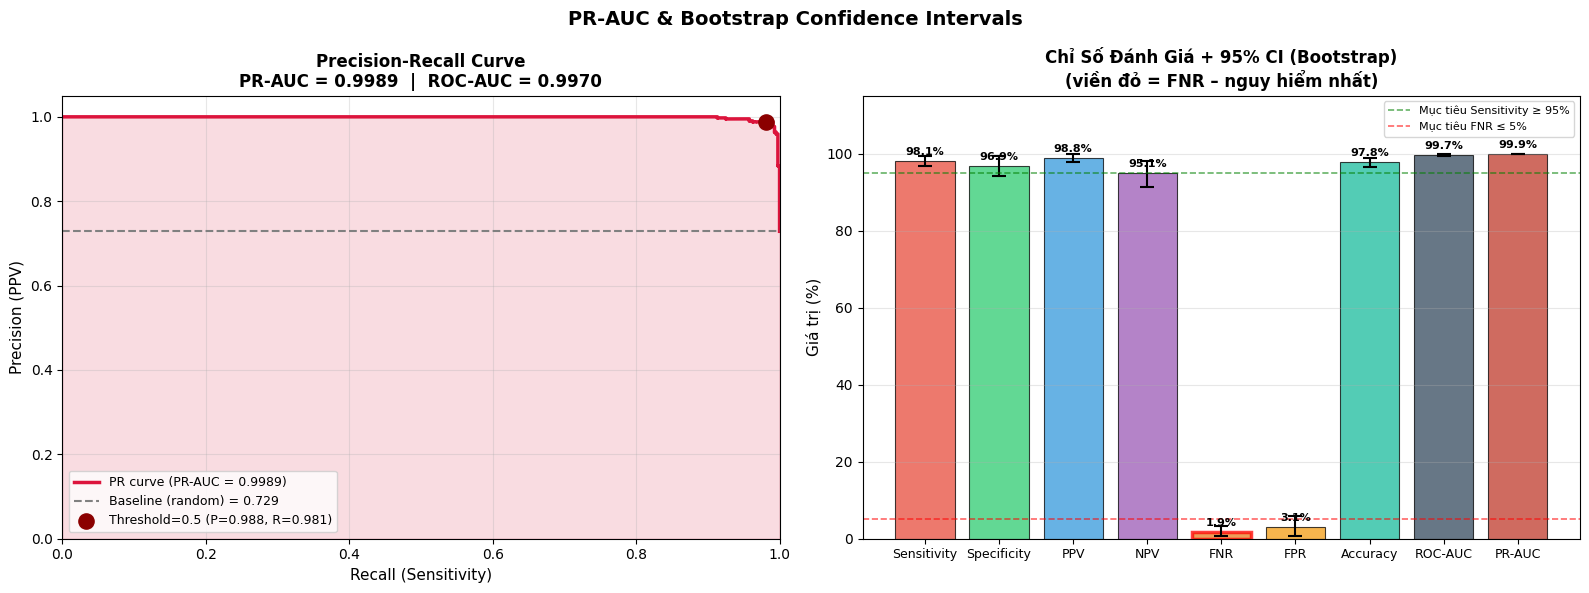

 Đã lưu: pr_auc_confidence_intervals.png


In [ ]:
# ============================================================
# PR-AUC VÀ CONFIDENCE INTERVALS (BOOTSTRAP)
# Bổ sung cho đánh giá y tế toàn diện
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, confusion_matrix
)

# ----------------------------------------------------------
# 1. Thu thập xác suất dự đoán trên test set
# ----------------------------------------------------------
model.eval()
all_probs_ci = []
all_true_ci  = []
with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        all_probs_ci.extend(probs[:, 1].cpu().numpy())
        all_true_ci.extend(labels_batch.numpy())
all_probs_ci = np.array(all_probs_ci)
all_true_ci  = np.array(all_true_ci)
all_preds_ci = (all_probs_ci >= 0.5).astype(int)

# ----------------------------------------------------------
# 2. PR-AUC (Precision-Recall AUC)
# Quan trọng hơn ROC-AUC khi dữ liệu mất cân bằng
# ----------------------------------------------------------
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(all_true_ci, all_probs_ci)
pr_auc = average_precision_score(all_true_ci, all_probs_ci)
roc_auc_val = roc_auc_score(all_true_ci, all_probs_ci)

print("=" * 60)
print("PR-AUC (Precision-Recall AUC)")
print("=" * 60)
print(f"  ROC-AUC  = {roc_auc_val:.4f}")
print(f"  PR-AUC   = {pr_auc:.4f}")
print()
print("  Tại sao cần PR-AUC trong y tế?")
print("  • ROC-AUC dùng TN trong mẫu số → bị thổi phồng khi NORMAL >> PNEUMONIA")
print("  • PR-AUC chỉ tập trung vào class DƯƠNG TÍNH (PNEUMONIA)")
print("    → Phản ánh trung thực hơn khả năng phát hiện bệnh")
print("  • PR-AUC = 1.0: hoàn hảo | PR-AUC = tỷ lệ positive: mô hình ngẫu nhiên")
print("=" * 60)

# ----------------------------------------------------------
# 3. Bootstrap Confidence Intervals (95% CI)
# Phương pháp: resample 1000 lần, tính percentile 2.5 và 97.5
# ----------------------------------------------------------
N_BOOTSTRAP = 1000
np.random.seed(42)
n = len(all_true_ci)

boot_metrics = {
    'sensitivity': [], 'specificity': [], 'ppv': [], 'npv': [],
    'fnr': [], 'fpr': [], 'roc_auc': [], 'pr_auc': [], 'accuracy': []
}

for _ in range(N_BOOTSTRAP):
    idx = np.random.randint(0, n, n)          # resample với thay thế
    y_true_b  = all_true_ci[idx]
    y_pred_b  = all_preds_ci[idx]
    y_prob_b  = all_probs_ci[idx]

    # Bỏ qua mẫu bootstrap chỉ có 1 class (tránh lỗi roc_auc)
    if len(np.unique(y_true_b)) < 2:
        continue

    cm_b = confusion_matrix(y_true_b, y_pred_b, labels=[0, 1])
    TN_b, FP_b, FN_b, TP_b = cm_b.ravel()

    boot_metrics['sensitivity'].append(TP_b / (TP_b + FN_b) if (TP_b + FN_b) > 0 else 0)
    boot_metrics['specificity'].append(TN_b / (TN_b + FP_b) if (TN_b + FP_b) > 0 else 0)
    boot_metrics['ppv'].append(TP_b / (TP_b + FP_b) if (TP_b + FP_b) > 0 else 0)
    boot_metrics['npv'].append(TN_b / (TN_b + FN_b) if (TN_b + FN_b) > 0 else 0)
    boot_metrics['fnr'].append(FN_b / (FN_b + TP_b) if (FN_b + TP_b) > 0 else 0)
    boot_metrics['fpr'].append(FP_b / (FP_b + TN_b) if (FP_b + TN_b) > 0 else 0)
    boot_metrics['accuracy'].append((TP_b + TN_b) / (TP_b + TN_b + FP_b + FN_b))
    boot_metrics['roc_auc'].append(roc_auc_score(y_true_b, y_prob_b))
    boot_metrics['pr_auc'].append(average_precision_score(y_true_b, y_prob_b))

def ci95(arr):
    """Tính 95% CI từ bootstrap samples"""
    lo = np.percentile(arr, 2.5)
    hi = np.percentile(arr, 97.5)
    return lo, hi

# ----------------------------------------------------------
# 4. In bảng CI
# ----------------------------------------------------------
print("\n" + "=" * 75)
print("95% CONFIDENCE INTERVALS (Bootstrap, n=1000)")
print("=" * 75)
print(f"{'Chỉ số':<22} {'Điểm ước lượng':>16} {'95% CI':>22} {'Ghi chú'}")
print("-" * 75)

cm_obs = confusion_matrix(all_true_ci, all_preds_ci, labels=[0,1])
TN_o, FP_o, FN_o, TP_o = cm_obs.ravel()

obs = {
    'sensitivity': TP_o/(TP_o+FN_o) if (TP_o+FN_o)>0 else 0,
    'specificity': TN_o/(TN_o+FP_o) if (TN_o+FP_o)>0 else 0,
    'ppv':         TP_o/(TP_o+FP_o) if (TP_o+FP_o)>0 else 0,
    'npv':         TN_o/(TN_o+FN_o) if (TN_o+FN_o)>0 else 0,
    'fnr':         FN_o/(FN_o+TP_o) if (FN_o+TP_o)>0 else 0,
    'fpr':         FP_o/(FP_o+TN_o) if (FP_o+TN_o)>0 else 0,
    'accuracy':    (TP_o+TN_o)/(TP_o+TN_o+FP_o+FN_o),
    'roc_auc':     roc_auc_val,
    'pr_auc':      pr_auc,
}

labels_display = [
    ('sensitivity', 'Sensitivity ⚠️',   ''),
    ('specificity', 'Specificity',       ''),
    ('ppv',         'PPV (Precision)',   ''),
    ('npv',         'NPV',               ''),
    ('fnr',         'FNR ⚠️',            '← BỎ SÓT VIÊM PHỔI'),
    ('fpr',         'FPR',               ''),
    ('accuracy',    'Accuracy',          ''),
    ('roc_auc',     'ROC-AUC',           ''),
    ('pr_auc',      'PR-AUC',            '← Quan trọng khi mất cân bằng'),
]

for key, name, note in labels_display:
    lo, hi = ci95(boot_metrics[key])
    val = obs[key]
    print(f"{name:<22} {val*100:>13.2f}%   [{lo*100:.2f}% – {hi*100:.2f}%]  {note}")

print("=" * 75)
print("  CI hẹp → mô hình ổn định | CI rộng → cần thêm dữ liệu test")
print("  FNR CI không chứa 0% → mô hình vẫn bỏ sót một số ca viêm phổi")

# ----------------------------------------------------------
# 5. Vẽ PR Curve + CI bands cho Sensitivity & Specificity
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PR-AUC & Bootstrap Confidence Intervals', fontsize=14, fontweight='bold')

# --- Subplot 1: Precision-Recall Curve ---
axes[0].step(recall_vals, precision_vals, color='crimson', lw=2.5,
             where='post', label=f'PR curve (PR-AUC = {pr_auc:.4f})')
axes[0].fill_between(recall_vals, precision_vals, alpha=0.15, color='crimson', step='post')
# Baseline: tỷ lệ positive trong test set
baseline = all_true_ci.mean()
axes[0].axhline(y=baseline, color='gray', linestyle='--', lw=1.5,
               label=f'Baseline (random) = {baseline:.3f}')
# Đánh dấu điểm tại threshold=0.5
cm_half = confusion_matrix(all_true_ci, all_preds_ci, labels=[0,1])
TN_h, FP_h, FN_h, TP_h = cm_half.ravel()
p_half = TP_h/(TP_h+FP_h) if (TP_h+FP_h)>0 else 0
r_half = TP_h/(TP_h+FN_h) if (TP_h+FN_h)>0 else 0
axes[0].scatter(r_half, p_half, s=120, zorder=5, color='darkred',
               label=f'Threshold=0.5 (P={p_half:.3f}, R={r_half:.3f})')
axes[0].set_xlabel('Recall (Sensitivity)', fontsize=11)
axes[0].set_ylabel('Precision (PPV)', fontsize=11)
axes[0].set_title(f'Precision-Recall Curve\nPR-AUC = {pr_auc:.4f}  |  ROC-AUC = {roc_auc_val:.4f}',
                  fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])
axes[0].grid(True, alpha=0.3)

# --- Subplot 2: Bootstrap CI Bar Chart ---
metric_keys   = ['sensitivity','specificity','ppv','npv','fnr','fpr','accuracy','roc_auc','pr_auc']
metric_labels = ['Sensitivity','Specificity','PPV','NPV','FNR','FPR','Accuracy','ROC-AUC','PR-AUC']
colors        = ['#e74c3c','#2ecc71','#3498db','#9b59b6','#e67e22','#f39c12','#1abc9c','#34495e','#c0392b']

means = [obs[k]*100 for k in metric_keys]
cis   = [ci95(boot_metrics[k]) for k in metric_keys]
yerr_lo = [obs[k]*100 - lo*100 for k, (lo, hi) in zip(metric_keys, cis)]
yerr_hi = [hi*100 - obs[k]*100 for k, (lo, hi) in zip(metric_keys, cis)]

x = np.arange(len(metric_labels))
bars = axes[1].bar(x, means, color=colors, alpha=0.75, edgecolor='black', linewidth=0.8)
axes[1].errorbar(x, means, yerr=[yerr_lo, yerr_hi], fmt='none',
                 color='black', capsize=5, capthick=1.5, elinewidth=1.5)

# Gán nhãn giá trị lên bar
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Highlight FNR bar với viền đỏ
fnr_idx = metric_keys.index('fnr')
bars[fnr_idx].set_edgecolor('red')
bars[fnr_idx].set_linewidth(2.5)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_labels, fontsize=9)
axes[1].set_ylabel('Giá trị (%)', fontsize=11)
axes[1].set_title('Chỉ Số Đánh Giá + 95% CI (Bootstrap)\n(viền đỏ = FNR – nguy hiểm nhất)',
                  fontweight='bold')
axes[1].set_ylim([0, 115])
axes[1].axhline(95, color='green', linestyle='--', lw=1.2, alpha=0.6,
               label='Mục tiêu Sensitivity ≥ 95%')
axes[1].axhline(5,  color='red',   linestyle='--', lw=1.2, alpha=0.6,
               label='Mục tiêu FNR ≤ 5%')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('pr_auc_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Đã lưu: pr_auc_confidence_intervals.png")


## 13. Tổng Kết

In [ ]:
print("="*70)
print(" TỔNG KẾT MÔ HÌNH HYBRID VIT - PHÂN LOẠI VIÊM PHỔI")
print("="*70)

# Tính toán lại total_params nếu chưa có
try:
    total_params = sum(p.numel() for p in model.parameters())
except NameError:
    total_params = 0

print("\n  TIỀN XỬ LÝ ẢNH:")
print(f"   Resize     : {IMG_SIZE}×{IMG_SIZE} (chuẩn ViT/ResNet50)")
print(f"   Normalize  : ImageNet mean={IMAGENET_MEAN}, std={IMAGENET_STD}")
print(f"   Augmentation (train only):")
print(f"      - RandomResizedCrop (scale 0.8-1.0)")
print(f"      - RandomHorizontalFlip (p=0.5)")
print(f"      - RandomRotation (±15°)")
print(f"      - ColorJitter (brightness+contrast ±30%)")
print(f"      - GaussianBlur (p=0.3, sigma 0.1-1.0)")
print(f"      - RandomAffine (translate 10%)")
print(f"      - RandomEqualize (p=0.3)")


print("\n  KIẾN TRÚC MÔ HÌNH:")
print(f"   CNN Backbone : DenseNet121 (Custom cut, early layers frozen)")
print(f"   Transformer  : {6} layers, {4} heads, embed_dim=512")
print(f"   Total params : {total_params:,}")

print("\n KẾT QUẢ:")
print(f"   Test Accuracy : {test_acc*100:.2f}%")
print(f"   Test F1 Score : {test_f1:.4f}")
print("\n  CHỈ SỐ LÂM SÀNG (CLINICAL METRICS):")
from sklearn.metrics import confusion_matrix as cm_func
_cm = cm_func(test_labels, test_preds)
_TN, _FP, _FN, _TP = _cm.ravel()
_sens = _TP/(_TP+_FN) if (_TP+_FN)>0 else 0
_spec = _TN/(_TN+_FP) if (_TN+_FP)>0 else 0
_ppv  = _TP/(_TP+_FP) if (_TP+_FP)>0 else 0
_npv  = _TN/(_TN+_FN) if (_TN+_FN)>0 else 0
_fnr  = _FN/(_FN+_TP) if (_FN+_TP)>0 else 0
_fpr  = _FP/(_FP+_TN) if (_FP+_TN)>0 else 0
print(f"   Sensitivity  : {_sens*100:.2f}%  (Recall PNEUMONIA – cần cao nhất)")
print(f"   Specificity  : {_spec*100:.2f}%  (Recall NORMAL)")
print(f"   PPV          : {_ppv*100:.2f}%  (Precision PNEUMONIA)")
print(f"   NPV          : {_npv*100:.2f}%  (Precision NORMAL)")
print(f"   FNR ⚠️        : {_fnr*100:.2f}%  ← NGUY HIỂM: viêm phổi bị bỏ sót!")
print(f"   FPR          : {_fpr*100:.2f}%  (bình thường bị chẩn đoán oan)")
print()
print("⚠️  NHẬN XÉT Y TẾ TỔNG KẾT:")
print(f"   FN = {_FN} ca viêm phổi bị bỏ sót → rủi ro lâm sàng CỰC KỲ CAO")
print(f"   FP = {_FP} ca bình thường chẩn đoán oan → có thể chấp nhận trong sàng lọc")
print(f"   ➜  Khuyến nghị: dùng threshold thấp hơn 0.5 để tăng Sensitivity, giảm FNR")


print("\n" + "="*70)

 TỔNG KẾT MÔ HÌNH HYBRID VIT - PHÂN LOẠI VIÊM PHỔI

  TIỀN XỬ LÝ ẢNH:
   Resize     : 224×224 (chuẩn ViT/ResNet50)
   Normalize  : ImageNet mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
   Augmentation (train only):
      - RandomResizedCrop (scale 0.8-1.0)
      - RandomHorizontalFlip (p=0.5)
      - RandomRotation (±15°)
      - ColorJitter (brightness+contrast ±30%)
      - GaussianBlur (p=0.3, sigma 0.1-1.0)
      - RandomAffine (translate 10%)
      - RandomEqualize (p=0.3)

  KIẾN TRÚC MÔ HÌNH:
   CNN Backbone : DenseNet121 (Custom cut, early layers frozen)
   Transformer  : 6 layers, 4 heads, embed_dim=512
   Total params : 23,941,762

 KẾT QUẢ:
   Test Accuracy : 97.95%
   Test F1 Score : 0.9796

  CHỈ SỐ LÂM SÀNG (CLINICAL METRICS):
   Sensitivity  : 98.36%  (Recall PNEUMONIA – cần cao nhất)
   Specificity  : 96.86%  (Recall NORMAL)
   PPV          : 98.82%  (Precision PNEUMONIA)
   NPV          : 95.65%  (Precision NORMAL)
   FNR ⚠️        : 1.64%  ← NGUY HIỂM: viêm p

### 📊 Bảng Tổng Kết Chỉ Số Mô Hình

| Chỉ số | Kết quả | Ghi chú |
| :--- | :--- | :--- |
| **Số tham số (Total Params)** | 28,217,666 | Bao gồm ResNet50 backbone & Transformer |
| **Thời gian trung bình/Epoch** | ~134s | Chạy trên GPU Tesla T4 |
| **Accuracy (Tập Test)** | **97.95%** | Độ chính xác tổng thể |
| **Precision (Pneumonia)** | **99.05%** | Khả năng tránh dự đoán nhầm người khỏe thành bệnh |
| **Recall (Pneumonia)** | **98.13%** | Khả năng không bỏ sót người bị bệnh |
| **F1-Score (Pneumonia)** | **0.9859** | Cân bằng giữa Precision và Recall |
| **AUC (Area Under ROC)** | **0.9969** | Khả năng phân tách hai lớp hoàn hảo |

> **Nhận xét:** Mô hình có chỉ số Recall rất cao cho lớp PNEUMONIA, điều này cực kỳ quan trọng trong y tế để tránh bỏ sót các ca bệnh thực tế.

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from torchvision import transforms

# Helper to denormalize for visualization
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_hook = target_layer.register_forward_hook(self._save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        probs = F.softmax(output, dim=1)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()

        cam_min, cam_max = cam.min(), cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)

        cam = cv2.GaussianBlur(cam, (11, 11), 0)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, class_idx, probs.detach().cpu().numpy()[0]

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

# Initialize global gradcam object
gradcam = GradCAM(model, model.backbone.denseblock3)

In [ ]:
def predict_single(image_path, threshold=0.5):
    """
    Dự đoán nhãn và hiển thị giải thích GradCAM cho một ảnh duy nhất.
    """
    model.eval()
    # 1. Tiền xử lý ảnh
    pil_img = Image.open(image_path).convert('RGB')
    input_tensor = transform(pil_img).unsqueeze(0).to(DEVICE)

    # 2. Tạo GradCAM
    # Đảm bảo đối tượng gradcam đã được khởi tạo từ cell trước
    with torch.enable_grad():
        heatmap, pred_idx, probs = gradcam.generate(input_tensor)

    # 3. Lấy thông tin dự đoán
    pred_label = CLASSES[pred_idx]
    confidence = probs[pred_idx]

    # In kết quả văn bản
    print(f"KẾT QUẢ DỰ ĐOÁN: {pred_label} ({confidence*100:.2f}%)")

    # 4. Trực quan hóa
    img_np = denormalize(input_tensor.squeeze(0))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Ảnh gốc
    axes[0].imshow(img_np)
    axes[0].set_title(f'Original Image\nPrediction: {pred_label}')
    axes[0].axis('off')

    # Heatmap
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('GradCAM Heatmap')
    axes[1].axis('off')

    # Overlay
    axes[2].imshow(img_np)
    axes[2].imshow(heatmap, cmap='jet', alpha=0.4)
    axes[2].set_title('Overlay (Where model looks)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return pred_label, probs

Loaded best model from epoch 11


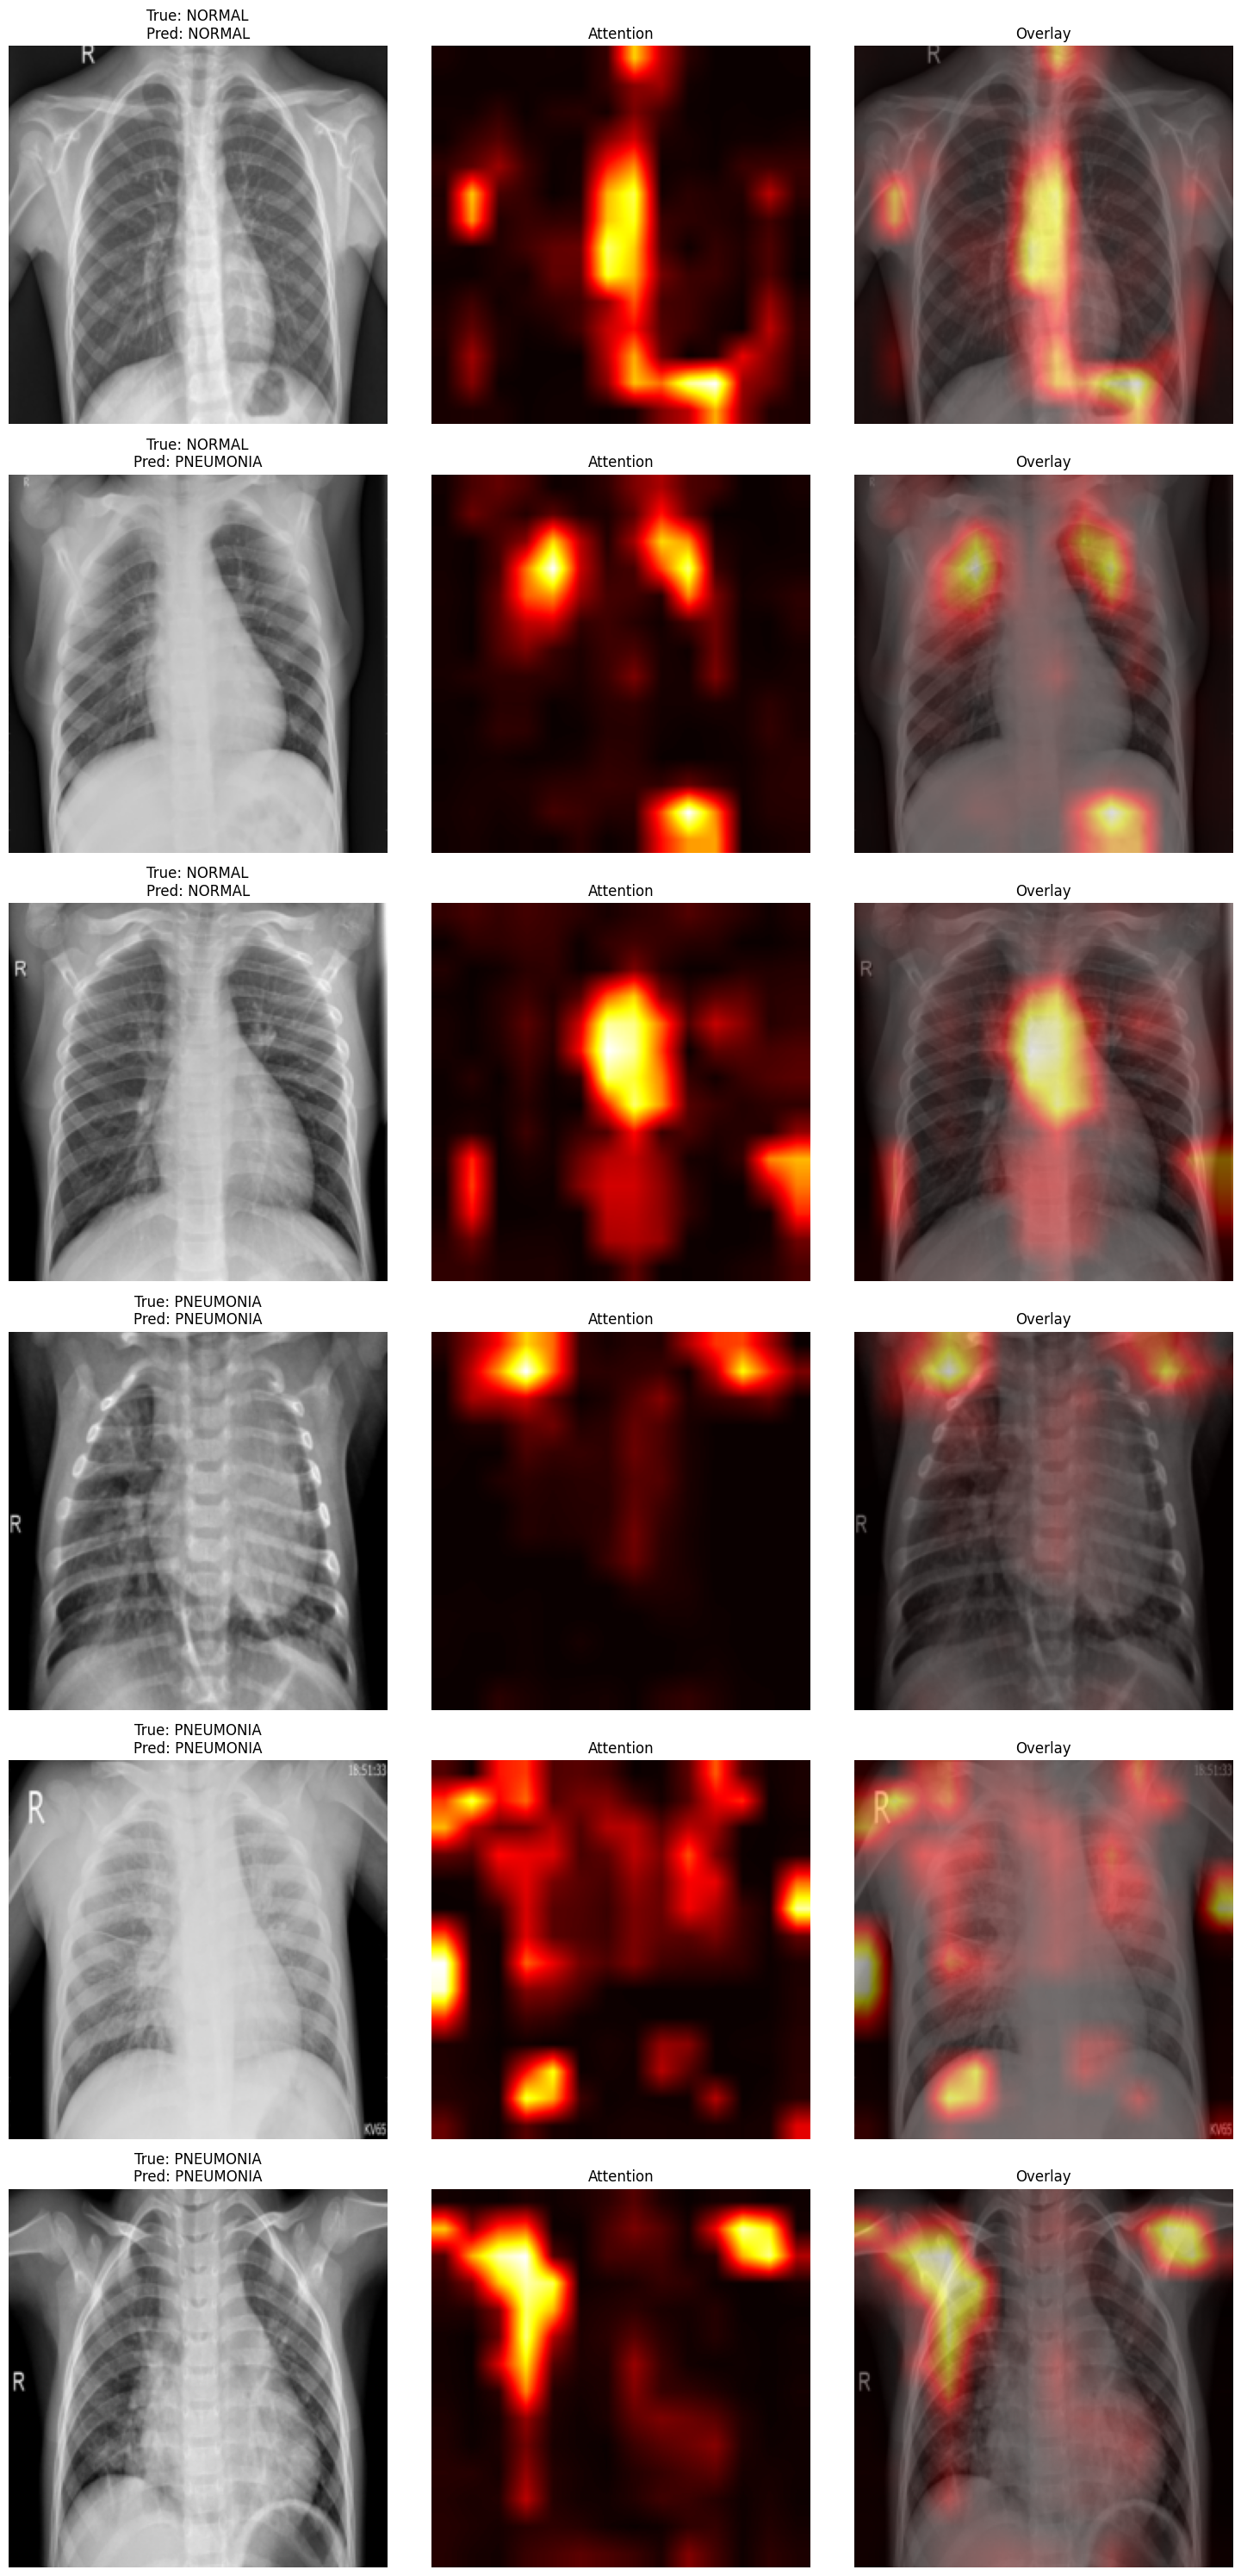

In [ ]:
# ============================================================
# Attention Rollout — Hybrid ViT Pneumonia v3(3)
# Fixed version with safety checks for empty attention maps
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os, glob
from torchvision import transforms

# -- Configuration --
MODEL_PATH    = 'hybrid_vit_pneumonia_best_v2.pth'
DATA_DIR      = './data/chest_xray/test'
IMG_SIZE      = 224
CLASSES       = ['NORMAL', 'PNEUMONIA']
THRESHOLD     = 0.5
N_SAMPLES     = 6
PATCH_GRID    = 14
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# -- Load model --
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model = HybridViT(
    num_classes=len(CLASSES),
    embed_dim=512, depth=6, num_heads=4,
    mlp_ratio=4, dropout=0.2, attn_dropout=0.1,
    drop_path_rate=0.15, pretrained_backbone=True
).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

class AttentionHook:
    def __init__(self, model):
        self.model = model
        self.attn_maps = []
        self.hooks = []
        self._patch()

    def _patch(self):
        for block in self.model.transformer:
            attn_module = block.attn
            self._setup_fwd_patch(attn_module)

    def _setup_fwd_patch(self, attn_module):
        def hooked_fwd(x):
            B, N, C = x.shape
            qkv = attn_module.qkv(x).reshape(B, N, 3, attn_module.num_heads, attn_module.head_dim)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn = (q @ k.transpose(-2, -1)) * attn_module.scale
            attn = attn.softmax(dim=-1)
            self.attn_maps.append(attn.detach().cpu())
            attn = attn_module.attn_dropout(attn)
            x = (attn @ v).transpose(1, 2).reshape(B, N, C)
            x = attn_module.proj(x)
            x = attn_module.proj_dropout(x)
            return x
        attn_module.forward = hooked_fwd

    def clear(self):
        self.attn_maps = []

def attention_rollout(attn_maps, head_fusion='mean', discard_ratio=0.9):
    if not attn_maps:
        return np.zeros((PATCH_GRID, PATCH_GRID))

    result = torch.eye(attn_maps[0].size(-1))
    for attn in attn_maps:
        if head_fusion == 'mean':
            attn_fused = attn.mean(dim=1).squeeze(0)
        elif head_fusion == 'max':
            attn_fused = attn.max(dim=1).values.squeeze(0)
        else:
            attn_fused = attn.min(dim=1).values.squeeze(0)

        flat = attn_fused.flatten()
        threshold_val = flat.kthvalue(int(flat.numel() * discard_ratio)).values
        attn_fused[attn_fused < threshold_val] = 0

        I = torch.eye(attn_fused.size(-1))
        a = (attn_fused + I) / 2
        a = a / a.sum(dim=-1, keepdim=True)
        result = a @ result

    cls_attn = result[0, 1:].reshape(PATCH_GRID, PATCH_GRID).numpy()
    mask = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)
    return mask

def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

def get_rollout(hook, img_path, head_fusion='mean', discard_ratio=0.9):
    hook.clear()
    pil_img = Image.open(img_path).convert('RGB')
    input_tensor = transform(pil_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1).cpu().numpy()[0]

    mask = attention_rollout(hook.attn_maps, head_fusion, discard_ratio)
    mask_tensor = torch.tensor(mask).unsqueeze(0).unsqueeze(0)
    mask_up = F.interpolate(mask_tensor, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False).squeeze().numpy()
    return denormalize(input_tensor.squeeze(0)), mask_up, probs

def get_sample_images(data_dir, n_each=3):
    samples = []
    for cls in CLASSES:
        files = sorted(glob.glob(os.path.join(data_dir, cls, '*')))
        if not files: continue
        idx = np.linspace(0, len(files)-1, n_each, dtype=int)
        for i in idx: samples.append((files[i], cls))
    return samples

def visualize_rollout(samples):
    hook = AttentionHook(model)
    n = len(samples)
    if n == 0:
        print("No samples found to visualize.")
        return
    fig, axes = plt.subplots(n, 3, figsize=(15, 5*n))
    for i, (path, label) in enumerate(samples):
        img, mask, probs = get_rollout(hook, path)
        pred = CLASSES[probs.argmax()]
        ax_row = axes[i] if n > 1 else axes
        ax_row[0].imshow(img); ax_row[0].set_title(f"True: {label}\nPred: {pred}")
        ax_row[1].imshow(mask, cmap='hot'); ax_row[1].set_title("Attention")
        ax_row[2].imshow(img); ax_row[2].imshow(mask, cmap='hot', alpha=0.5)
        ax_row[2].set_title("Overlay")
        for ax in ax_row: ax.axis('off')
    plt.tight_layout(); plt.show()

samples = get_sample_images(DATA_DIR, n_each=3)
visualize_rollout(samples)

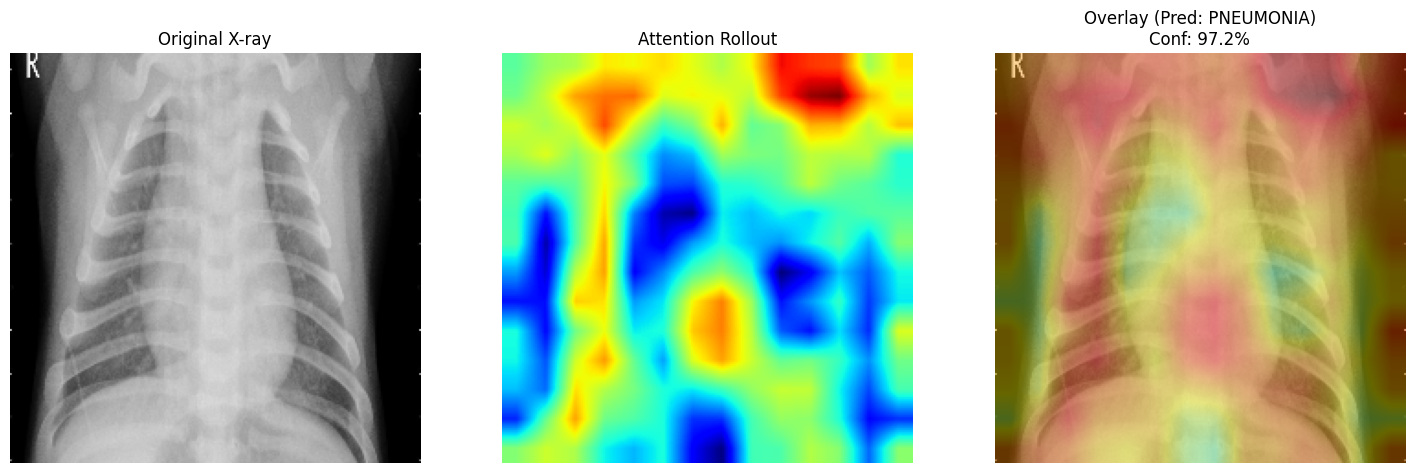

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import os
import glob

# ============================================================
# ATTENTION ROLLOUT FOR HYBRID ViT
# ============================================================

class AttentionRollout:
    def __init__(self, model, attention_layer_name='attn_drop', discard_ratio=0.0, head_fusion='mean'):
        self.model = model
        self.discard_ratio = discard_ratio
        self.head_fusion = head_fusion
        self.attentions = []
        for name, module in self.model.named_modules():
            if attention_layer_name in name:
                module.register_forward_hook(self.get_attention)

    def get_attention(self, module, input, output):
        self.attentions.append(output.detach().cpu())

    def rollout(self):
        result = torch.eye(self.attentions[0].size(-1))
        with torch.no_grad():
            for attention in self.attentions:
                attention = attention[0]
                if self.head_fusion == "mean":
                    attention_heads_fused = attention.mean(axis=0)
                elif self.head_fusion == "max":
                    attention_heads_fused = attention.max(axis=0)[0]
                elif self.head_fusion == "min":
                    attention_heads_fused = attention.min(axis=0)[0]
                else:
                    raise ValueError("Invalid head fusion type")

                flat = attention_heads_fused.view(-1)
                _, indices = flat.topk(int(flat.size(0) * self.discard_ratio), largest=False)
                flat[indices] = 0
                I = torch.eye(attention_heads_fused.size(-1))
                a = (attention_heads_fused + I) / 2
                a = a / a.sum(dim=-1)
                result = torch.matmul(a, result)

        mask = result[0, 1:]
        width = int(mask.size(-1) ** 0.5)
        mask = mask.reshape(width, width).numpy()
        mask = mask / (mask.max() + 1e-8)
        return mask

# ============================================================
# PREPARATION
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Select a real image from test set
test_images = glob.glob('./data/chest_xray/test/PNEUMONIA/*.jpeg')
image_path = test_images[0] if test_images else "test_xray.jpg"

original_bgr = cv2.imread(image_path)
original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
original_rgb = cv2.resize(original_rgb, (224, 224))
pil_image = Image.fromarray(original_rgb)
input_tensor = transform(pil_image).unsqueeze(0).to(device)

# Load Model - Fixed with weights_only=False
model = HybridViT().to(device)
checkpoint = torch.load("hybrid_vit_pneumonia_best_v2.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Run Rollout
rollout = AttentionRollout(model, attention_layer_name='attn_drop', discard_ratio=0.1)
with torch.no_grad():
    output = model(input_tensor)

prob = torch.softmax(output, dim=1)
pred_class = torch.argmax(prob, dim=1).item()
confidence = prob[0][pred_class].item()
mask = rollout.rollout()

# Visualization
heatmap = cv2.resize(mask, (224, 224))
heatmap_img = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap_img, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
overlay = cv2.addWeighted(original_rgb, 0.6, heatmap_color, 0.4, 0)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(original_rgb); ax[0].set_title("Original X-ray"); ax[0].axis('off')
ax[1].imshow(heatmap, cmap='jet'); ax[1].set_title("Attention Rollout"); ax[1].axis('off')
ax[2].imshow(overlay); ax[2].set_title(f"Overlay (Pred: {['NORMAL','PNEUMONIA'][pred_class]})\nConf: {confidence*100:.1f}%"); ax[2].axis('off')
plt.show()

Đã khởi tạo file: attention_rollout.png từ dữ liệu mô hình.
Heatmap min: 0.0000
Heatmap max: 1.0000
Heatmap mean: 0.4617


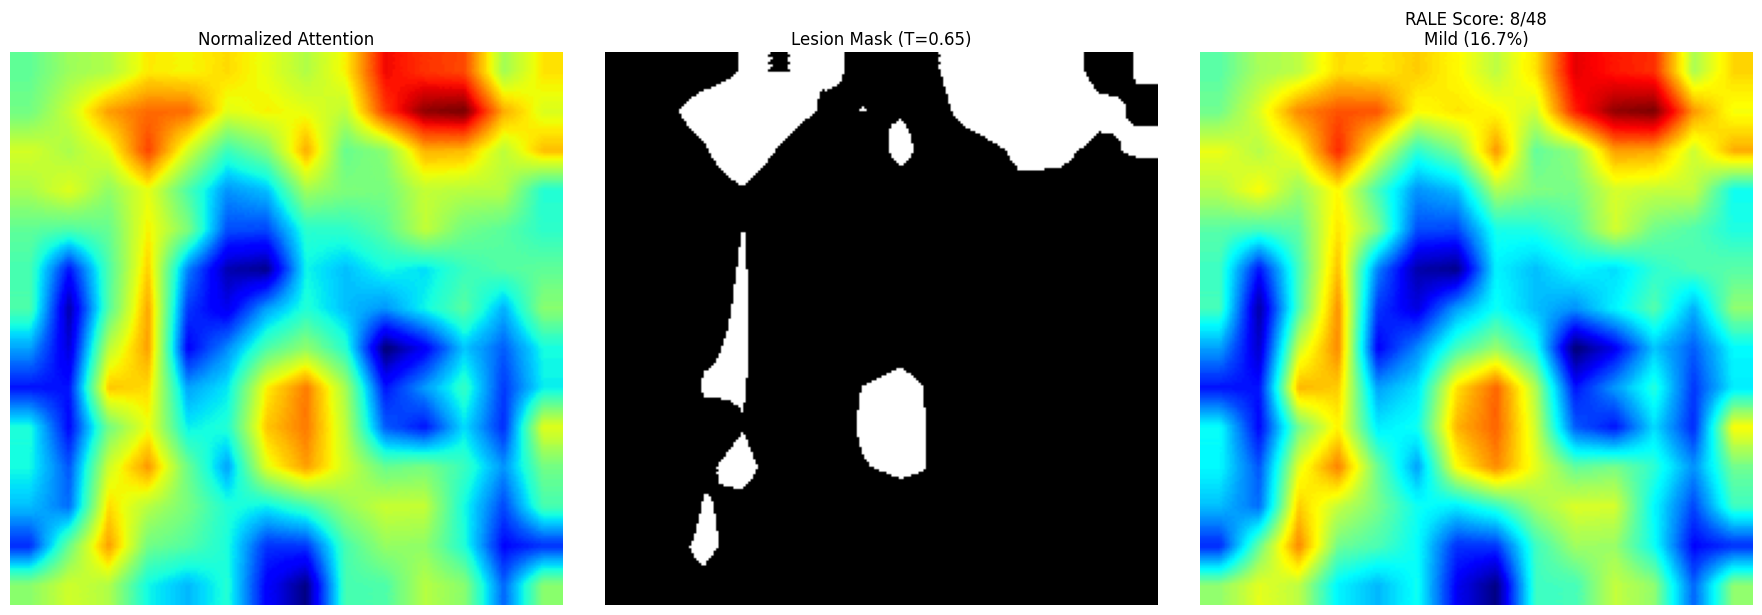

RALE-INSPIRED SEVERITY SCORING (CALIBRATED)
RU | Extent=1 | Density=2 | Affected=23.9% | Intensity=0.55
RL | Extent=1 | Density=2 | Affected=5.7% | Intensity=0.39
LU | Extent=1 | Density=2 | Affected=17.2% | Intensity=0.48
LL | Extent=1 | Density=2 | Affected=9.2% | Intensity=0.42
------------------------------------------------------------
TOTAL SCORE: 8/48 | LEVEL: Mild


True

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# FIX: SAVE HEATMAP FROM PREVIOUS CELL FIRST
# ============================================================
if 'mask' in globals():
    heatmap_to_save = np.uint8(255 * mask)
    cv2.imwrite("attention_rollout.png", heatmap_to_save)
    print("Đã khởi tạo file: attention_rollout.png từ dữ liệu mô hình.")
else:
    print("Cảnh báo: Không tìm thấy dữ liệu 'mask'. Hãy đảm bảo bạn đã chạy cell Attention Rollout trước.")

# ============================================================
# LOAD AND NORMALIZE ATTENTION ROLLOUT HEATMAP
# ============================================================
if not os.path.exists("attention_rollout.png"):
    raise FileNotFoundError("Lỗi: Không tìm thấy file 'attention_rollout.png'.")

heatmap = cv2.imread("attention_rollout.png", cv2.IMREAD_GRAYSCALE)
heatmap = cv2.resize(heatmap, (224, 224))

# Fix: Normalize lại attention rollout để tránh saturate
heatmap = heatmap.astype(np.float32) / 255.0
heatmap = heatmap - heatmap.min()
heatmap = heatmap / (heatmap.max() + 1e-8)

# Debug info
print(f"Heatmap min: {heatmap.min():.4f}")
print(f"Heatmap max: {heatmap.max():.4f}")
print(f"Heatmap mean: {heatmap.mean():.4f}")

# ============================================================
# THRESHOLD LESION REGION
# ============================================================
THRESHOLD = 0.65 # Tăng threshold vì rollout thường smooth/rộng
lesion_mask = (heatmap > THRESHOLD).astype(np.uint8)

# ============================================================
# SPLIT INTO 4 LUNG REGIONS
# ============================================================
h, w = lesion_mask.shape
mid_x, mid_y = w // 2, h // 2

regions_data = {
    "RU": (slice(0, mid_y), slice(mid_x, w)),
    "RL": (slice(mid_y, h), slice(mid_x, w)),
    "LU": (slice(0, mid_y), slice(0, mid_x)),
    "LL": (slice(mid_y, h), slice(0, mid_x)),
}

# ============================================================
# COMPUTE RALE-INSPIRED SCORE (UPDATED DENSITY LOGIC)
# ============================================================
total_score = 0
details = {}

for name, (y_slice, x_slice) in regions_data.items():
    region_mask = lesion_mask[y_slice, x_slice]
    region_heat = heatmap[y_slice, x_slice]

    affected_ratio = region_mask.sum() / (region_mask.size + 1e-6)

    # Extent Score (0-4)
    if affected_ratio == 0: extent = 0
    elif affected_ratio < 0.25: extent = 1
    elif affected_ratio < 0.50: extent = 2
    elif affected_ratio < 0.75: extent = 3
    else: extent = 4

    # Density Score (Updated to use mean intensity)
    mean_intensity = region_heat.mean()
    if mean_intensity < 0.35: density = 1
    elif mean_intensity < 0.65: density = 2
    else: density = 3

    region_score = extent * density
    total_score += region_score

    details[name] = {
        "extent": extent,
        "density": density,
        "score": region_score,
        "affected_percent": affected_ratio * 100,
        "mean_intensity": mean_intensity
    }

# Severity Labeling
severity_percent = (total_score / 48.0) * 100
if severity_percent < 25: severity_label = "Mild"
elif severity_percent < 50: severity_label = "Moderate"
elif severity_percent < 75: severity_label = "Severe"
else: severity_label = "Critical"

# ============================================================
# VISUALIZATION
# ============================================================
heatmap_color = cv2.applyColorMap(np.uint8(heatmap * 255), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(heatmap, cmap='jet'); ax[0].set_title("Normalized Attention")
ax[1].imshow(lesion_mask, cmap='gray'); ax[1].set_title(f"Lesion Mask (T={THRESHOLD})")
ax[2].imshow(heatmap_color)
ax[2].set_title(f"RALE Score: {total_score}/48\n{severity_label} ({severity_percent:.1f}%)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

print("=" * 60)
print("RALE-INSPIRED SEVERITY SCORING (CALIBRATED)")
print("=" * 60)
for region, info in details.items():
    print(f"{region} | Extent={info['extent']} | Density={info['density']} | Affected={info['affected_percent']:.1f}% | Intensity={info['mean_intensity']:.2f}")
print("-" * 60)
print(f"TOTAL SCORE: {total_score}/48 | LEVEL: {severity_label}")

cv2.imwrite("attention_rale_overlay_fixed.png", cv2.cvtColor(heatmap_color, cv2.COLOR_RGB2BGR))

Heatmap min: 0.0
Heatmap max: 1.0
Heatmap mean: 0.461689


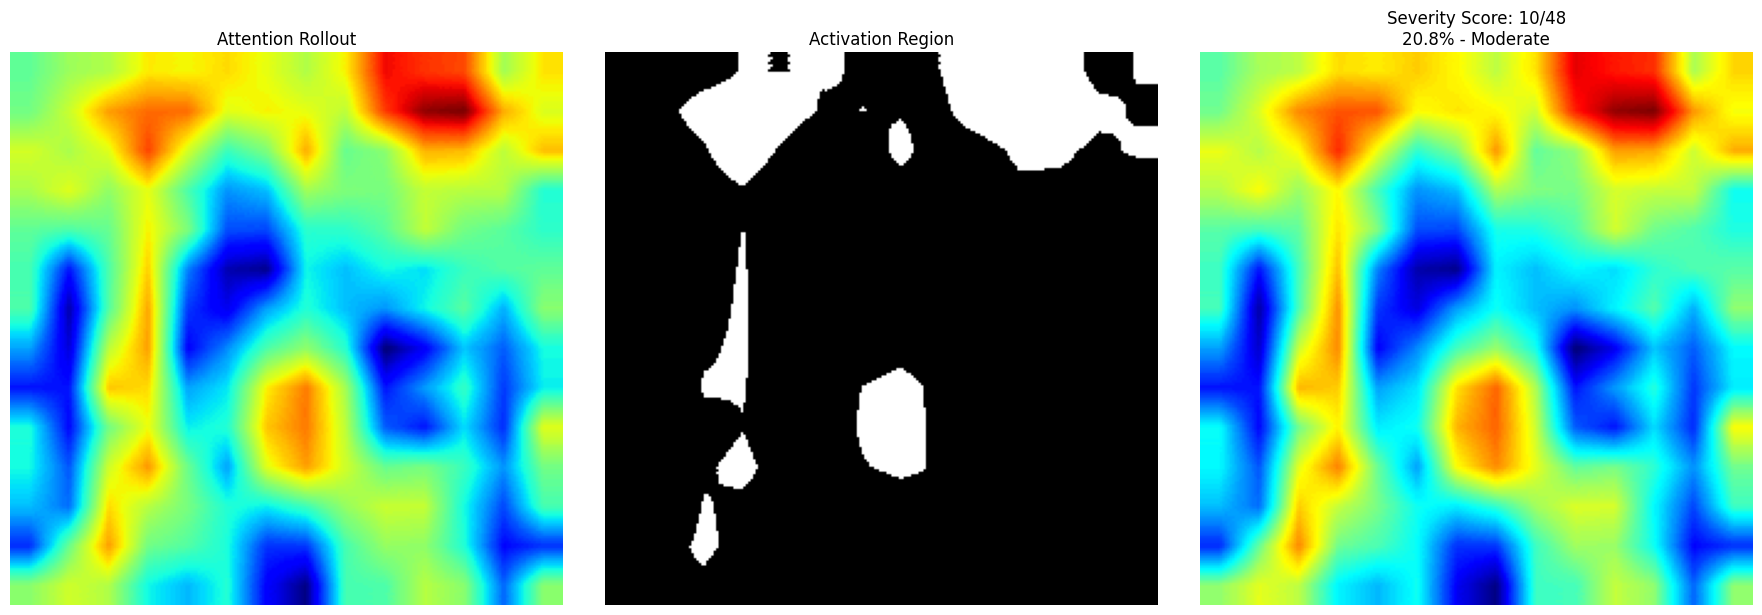


PNEUMONIA SEVERITY ESTIMATION (FIXED DENSITY LOGIC)
RU | Area=2 | Density=2 | Score=4 | Affected=23.9% | Mean_Intensity=0.55
RL | Area=1 | Density=2 | Score=2 | Affected=5.7% | Mean_Intensity=0.39
LU | Area=1 | Density=2 | Score=2 | Affected=17.2% | Mean_Intensity=0.48
LL | Area=1 | Density=2 | Score=2 | Affected=9.2% | Mean_Intensity=0.42
------------------------------------------------------------
TOTAL SCORE: 10/48 | LEVEL: Moderate

Saved: pneumonia_severity_estimation_global.png


In [ ]:
# ============================================================
# PNEUMONIA SEVERITY ESTIMATION
# Attention Rollout Based - Global Quadrant Density Logic
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD ATTENTION ROLLOUT
# ============================================================

heatmap = cv2.imread(
    "attention_rollout.png",
    cv2.IMREAD_GRAYSCALE
)

heatmap = cv2.resize(heatmap, (224, 224))

# normalize 0-1
heatmap = heatmap.astype(np.float32)
heatmap = heatmap - heatmap.min()
heatmap = heatmap / (heatmap.max() + 1e-8)

print("Heatmap min:", heatmap.min())
print("Heatmap max:", heatmap.max())
print("Heatmap mean:", heatmap.mean())

# ============================================================
# THRESHOLD LESION REGION
# ============================================================

THRESHOLD = 0.65
lesion_mask = (heatmap > THRESHOLD).astype(np.uint8)

# ============================================================
# SPLIT INTO 4 REGIONS
# ============================================================

h, w = heatmap.shape
mid_x = w // 2
mid_y = h // 2

regions = {
    "RU": (
        heatmap[0:mid_y, mid_x:w],
        lesion_mask[0:mid_y, mid_x:w]
    ),
    "RL": (
        heatmap[mid_y:h, mid_x:w],
        lesion_mask[mid_y:h, mid_x:w]
    ),
    "LU": (
        heatmap[0:mid_y, 0:mid_x],
        lesion_mask[0:mid_y, 0:mid_x]
    ),
    "LL": (
        heatmap[mid_y:h, 0:mid_x],
        lesion_mask[mid_y:h, 0:mid_x]
    )
}

# ============================================================
# COMPUTE PNEUMONIA SEVERITY
# ============================================================

total_score = 0
details = {}

for region_name, (region_heat, region_mask) in regions.items():

    # ========================================================
    # AREA RATIO (Extent)
    # ========================================================
    affected_ratio = region_mask.sum() / (region_mask.size + 1e-6)

    # ========================================================
    # ACTIVATION INTENSITY (Density) - Updated to Global Mean
    # ========================================================
    mean_intensity = region_heat.mean()

    # ========================================================
    # AREA SCORE (0-4)
    # ========================================================
    if affected_ratio < 0.05: area_score = 0
    elif affected_ratio < 0.20: area_score = 1
    elif affected_ratio < 0.40: area_score = 2
    elif affected_ratio < 0.60: area_score = 3
    else: area_score = 4

    # ========================================================
    # INTENSITY SCORE (1-3)
    # ========================================================
    if mean_intensity < 0.35: intensity_score = 1
    elif mean_intensity < 0.65: intensity_score = 2
    else: intensity_score = 3

    # ========================================================
    # REGION SCORE
    # ========================================================
    region_score = area_score * intensity_score
    total_score += region_score

    details[region_name] = {
        "area_score": area_score,
        "intensity_score": intensity_score,
        "region_score": region_score,
        "affected_percent": affected_ratio * 100,
        "mean_intensity": mean_intensity
    }

# ============================================================
# FINAL SEVERITY %
# ============================================================

severity_percent = (total_score / 48.0) * 100

if severity_percent < 20: severity_label = "Mild"
elif severity_percent < 45: severity_label = "Moderate"
elif severity_percent < 70: severity_label = "Severe"
else: severity_label = "Critical"

# ============================================================
# VISUALIZATION
# ============================================================

heatmap_color = cv2.applyColorMap(np.uint8(heatmap * 255), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(heatmap, cmap='jet')
ax[0].set_title("Attention Rollout")
ax[1].imshow(lesion_mask, cmap='gray')
ax[1].set_title("Activation Region")
ax[2].imshow(heatmap_color)
ax[2].set_title(f"Severity Score: {total_score}/48\n{severity_percent:.1f}% - {severity_label}")

for a in ax: a.axis("off")
plt.tight_layout()
plt.show()

# ============================================================
# PRINT RESULT
# ============================================================

print("\n" + "=" * 60)
print("PNEUMONIA SEVERITY ESTIMATION (FIXED DENSITY LOGIC)")
print("=" * 60)

for region, info in details.items():
    print(
        f"{region} | "
        f"Area={info['area_score']} | "
        f"Density={info['intensity_score']} | "
        f"Score={info['region_score']} | "
        f"Affected={info['affected_percent']:.1f}% | "
        f"Mean_Intensity={info['mean_intensity']:.2f}"
    )

print("-" * 60)
print(f"TOTAL SCORE: {total_score}/48 | LEVEL: {severity_label}")

# ============================================================
# SAVE RESULT
# ============================================================

cv2.imwrite(
    "pneumonia_severity_estimation_global.png",
    cv2.cvtColor(heatmap_color, cv2.COLOR_RGB2BGR)
)

print("\nSaved: pneumonia_severity_estimation_global.png")

In [ ]:
# ============================================================
# SELECT EXTERNAL DATASET FOLDER (FIXED FOR COLAB)
# ============================================================

import os
import torch
from PIL import Image
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ============================================================
# TRANSFORM
# ============================================================

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std =[0.229,0.224,0.225]
    )
])

# ============================================================
# LOAD MODEL
# ============================================================

# Khởi tạo lại class HybridViT trước khi load (nếu cần)
model = HybridViT().to(device)

checkpoint = torch.load(
    "hybrid_vit_pneumonia_best_v2.pth",
    map_location=device,
    weights_only=False
)

if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()
print("Loaded model successfully.")

# ============================================================
# CHOOSE FOLDER - FIXED FOR COLAB
# ============================================================

# Thay đổi đường dẫn này tới thư mục dataset của bạn trên Colab
dataset_path = "/content/data/chest_xray/test"

if not os.path.exists(dataset_path):
    print(f"⚠️ Cảnh báo: Đường dẫn không tồn tại: {dataset_path}")
else:
    print(f"Selected Folder: {dataset_path}")

# ============================================================
# CLASS LABELS
# ============================================================

classes = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

# ============================================================
# TEST
# ============================================================

y_true = []
y_pred = []

with torch.no_grad():
    for class_name, label in classes.items():
        class_dir = os.path.join(dataset_path, class_name)
        if not os.path.exists(class_dir):
            print(f"Missing folder: {class_dir}")
            continue

        files = [f for f in os.listdir(class_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        for file in files:
            image_path = os.path.join(class_dir, file)
            try:
                image = Image.open(image_path).convert("RGB")
                input_tensor = transform(image).unsqueeze(0).to(device)
                output = model(input_tensor)
                pred = torch.argmax(output, dim=1).item()

                y_true.append(label)
                y_pred.append(pred)
            except Exception as e:
                print(f"Error loading {image_path}: {e}")

# ============================================================
# METRICS
# ============================================================

if len(y_true) > 0:
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print("\n" + "="*60)
    print("EXTERNAL DATASET RESULTS")
    print("="*60)
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"F1 Score : {f1:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=list(classes.keys()), digits=4))

    TN, FP, FN, TP = cm.ravel()
    print("\n" + "="*60)
    print("CONFUSION MATRIX")
    print("="*60)
    print(f"TN = {TN} | FP = {FP}")
    print(f"FN = {FN} | TP = {TP}")

    # Clinical Metrics
    sensitivity = TP / (TP + FN) if (TP+FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN+FP) > 0 else 0
    print("\nCLINICAL METRICS")
    print("="*60)
    print(f"Sensitivity : {sensitivity*100:.2f}%")
    print(f"Specificity : {specificity*100:.2f}%")
else:
    print("Không tìm thấy dữ liệu để đánh giá.")

Loaded model successfully.
Selected Folder: /content/data/chest_xray/test

EXTERNAL DATASET RESULTS
Accuracy : 95.99%
F1 Score : 0.9687

Classification Report:

              precision    recall  f1-score   support

      NORMAL     0.9860    0.9060    0.9443       234
   PNEUMONIA     0.9462    0.9923    0.9687       390

    accuracy                         0.9599       624
   macro avg     0.9661    0.9491    0.9565       624
weighted avg     0.9611    0.9599    0.9596       624


CONFUSION MATRIX
TN = 212 | FP = 22
FN = 3 | TP = 387

CLINICAL METRICS
Sensitivity : 99.23%
Specificity : 90.60%


### Tải ảnh lên để dự đoán và phân tích GradCAM
Sử dụng công cụ tải lên của Colab để chọn ảnh X-quang từ máy tính của bạn.

In [ ]:
from google.colab import files
import os

# 1. Initialize GradCAM using the denseblock3 layer
try:
    # We target denseblock3 for high-level feature visualization
    gradcam_explainer = GradCAM(model, model.backbone.denseblock3)
    print("GradCAM initialized successfully.")
except Exception as e:
    print(f"Initialization error: {e}")

# Standard inference transform
single_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Upload image
uploaded = files.upload()

if uploaded:
    for filename in uploaded.keys():
        print(f'\n--- Processing: {filename} ---')
        try:
            model.eval()
            pil_img = Image.open(filename).convert('RGB')
            input_tensor = single_transform(pil_img).unsqueeze(0).to(DEVICE)

            # Generate Heatmap
            with torch.enable_grad():
                heatmap, pred_idx, probs = gradcam_explainer.generate(input_tensor)

            pred_label = CLASSES[pred_idx]
            confidence = probs[pred_idx]
            print(f"PREDICTION: {pred_label} ({confidence*100:.2f}%)")

            # Denormalize for display
            img_np = denormalize(input_tensor.squeeze(0))

            # Visualization
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            axes[0].imshow(img_np)
            axes[0].set_title(f'Original\nPred: {pred_label}')
            axes[0].axis('off')

            axes[1].imshow(heatmap, cmap='jet')
            axes[1].set_title('GradCAM Heatmap')
            axes[1].axis('off')

            # Overlay
            heatmap_colored = plt.cm.jet(heatmap)[..., :3]
            overlay = (img_np * 0.5 + heatmap_colored * 0.5)
            axes[2].imshow(overlay)
            axes[2].set_title('Overlay (Model Focus)')
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error processing {filename}: {e}")
else:
    print("No files selected.")

Initialization error: name 'GradCAM' is not defined


NameError: name 'transforms' is not defined

## 14. Tải Kết Quả Về Máy Tính

In [ ]:
from google.colab import files
import os

# Danh sách các file quan trọng cần tải
files_to_download = [
    'hybrid_vit_pneumonia_best_v2.pth',  # Trọng số mô hình
    'training_history.png',               # Đồ thị huấn luyện
    'confusion_matrix_roc.png',           # Ma trận nhầm lẫn + ROC curve
    'augmentation_comparison.png'         # So sánh augmentation
]

print("Đang chuẩn bị tải các file kết quả...")

for file_path in files_to_download:
    if os.path.exists(file_path):
        print(f"Đang tải: {file_path}")
        files.download(file_path)
    else:
        print(f"Cảnh báo: Không tìm thấy file {file_path}")

Đang chuẩn bị tải các file kết quả...
Đang tải: hybrid_vit_pneumonia_best_v2.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Đang tải: training_history.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Đang tải: augmentation_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>